<a href="https://colab.research.google.com/github/xchan166/Motor-Thermal-Anomaly-Detection/blob/main/Motor_Thermal_Predictive_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Dataset Setup

This experiment uses the thermal image dataset:

Najafi et al., "Thermal image of equipment (Induction Motor) + 40 Ground Truths added," Mendeley Data, Version 3.

DOI: 10.17632/m4sbt8hbvk.3

Download the dataset and place it in Google Drive before running the following cells.

ขั้นตอนที่ 1: เชื่อม Google Drive และกำหนดตำแหน่ง Dataset

เปิด Google Colab แล้วสร้าง Cell ใหม่ จากนั้นรันโค้ดนี้

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

DATASET_ROOT = Path(
    "/content/drive/MyDrive/Datasets/"
    "Thermal image of equipment (Induction Motor) + 40 Ground Truths added"
)

print("Dataset path:", DATASET_ROOT)
print("Path exists:", DATASET_ROOT.exists())

Dataset path: /content/drive/MyDrive/Datasets/Thermal image of equipment (Induction Motor) + 40 Ground Truths added
Path exists: True


In [ ]:
for path in DATASET_ROOT.rglob("IR-Motor-bmp"):
    print("พบโฟลเดอร์ภาพหลัก:", path)

พบโฟลเดอร์ภาพหลัก: /content/drive/MyDrive/Datasets/Thermal image of equipment (Induction Motor) + 40 Ground Truths added/IR-Motor-bmp


In [ ]:
MOTOR_DIR = next(DATASET_ROOT.rglob("IR-Motor-bmp"))

print("MOTOR_DIR:", MOTOR_DIR)
print("Path exists:", MOTOR_DIR.exists())

MOTOR_DIR: /content/drive/MyDrive/Datasets/Thermal image of equipment (Induction Motor) + 40 Ground Truths added/IR-Motor-bmp
Path exists: True


Phase 2 : ตรวจจำนวนภาพในแต่ละโฟลเดอร์

In [ ]:
from pathlib import Path
import pandas as pd

# ==============================
# Count images in each folder
# ==============================

IMAGE_EXTS = {".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff"}

rows = []

for folder in sorted(MOTOR_DIR.iterdir()):

    if not folder.is_dir():
        continue

    images = [
        f for f in folder.iterdir()
        if f.suffix.lower() in IMAGE_EXTS
    ]

    rows.append({
        "Folder": folder.name,
        "Images": len(images)
    })

df_count = pd.DataFrame(rows)

df_count = df_count.sort_values("Folder").reset_index(drop=True)

display(df_count)

print("----------------------------------")
print("Total Images :", df_count["Images"].sum())
print("Total Folder :", len(df_count))

,Folder,Images
0,A&B50,38
1,A&C&B10,31
2,A&C&B30,42
3,A&C10,31
4,A&C30,38
5,A10,34
6,A30,37
7,A50,35
8,Fan,28
9,Noload,25


----------------------------------
Total Images : 369
Total Folder : 11


In [ ]:
df_count["Binary Label"] = df_count["Folder"].apply(
    lambda x: "Normal" if x == "Noload" else "Abnormal"
)

display(df_count)

,Folder,Images,Binary Label
0,A&B50,38,Abnormal
1,A&C&B10,31,Abnormal
2,A&C&B30,42,Abnormal
3,A&C10,31,Abnormal
4,A&C30,38,Abnormal
5,A10,34,Abnormal
6,A30,37,Abnormal
7,A50,35,Abnormal
8,Fan,28,Abnormal
9,Noload,25,Normal


Figure 5. Distribution of Images in Each Fault Class

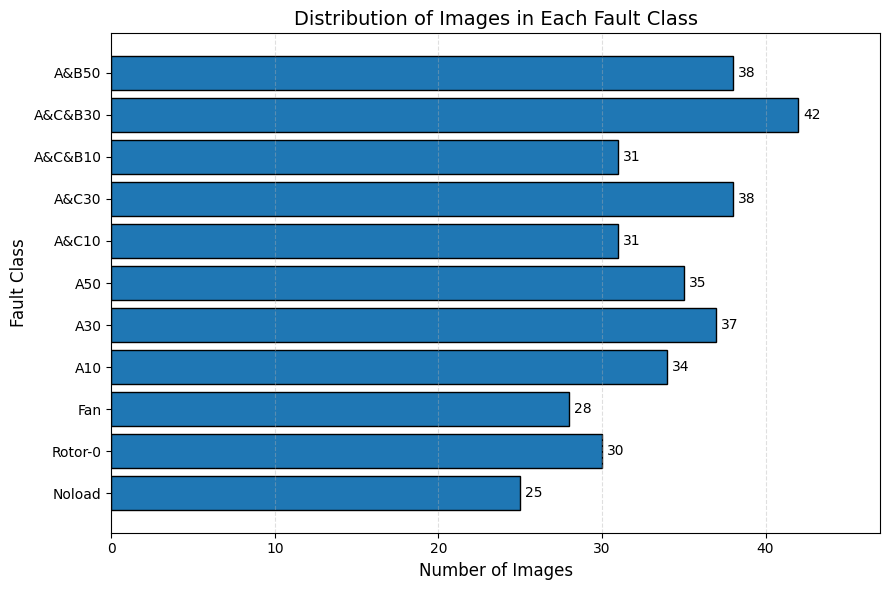

In [ ]:
import matplotlib.pyplot as plt

# เรียงลำดับตามลักษณะของข้อมูล
order = [
    "Noload",
    "Rotor-0",
    "Fan",
    "A10",
    "A30",
    "A50",
    "A&C10",
    "A&C30",
    "A&C&B10",
    "A&C&B30",
    "A&B50"
]

plot_df = (
    df_count.set_index("Folder")
            .loc[order]
            .reset_index()
)

plt.figure(figsize=(9,6))

bars = plt.barh(
    plot_df["Folder"],
    plot_df["Images"],
    edgecolor='black'
)

# แสดงจำนวนภาพบนแท่งกราฟ
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        fontsize=10
    )

plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Fault Class", fontsize=12)
plt.title("Distribution of Images in Each Fault Class", fontsize=14)

plt.xlim(0, max(plot_df["Images"]) + 5)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

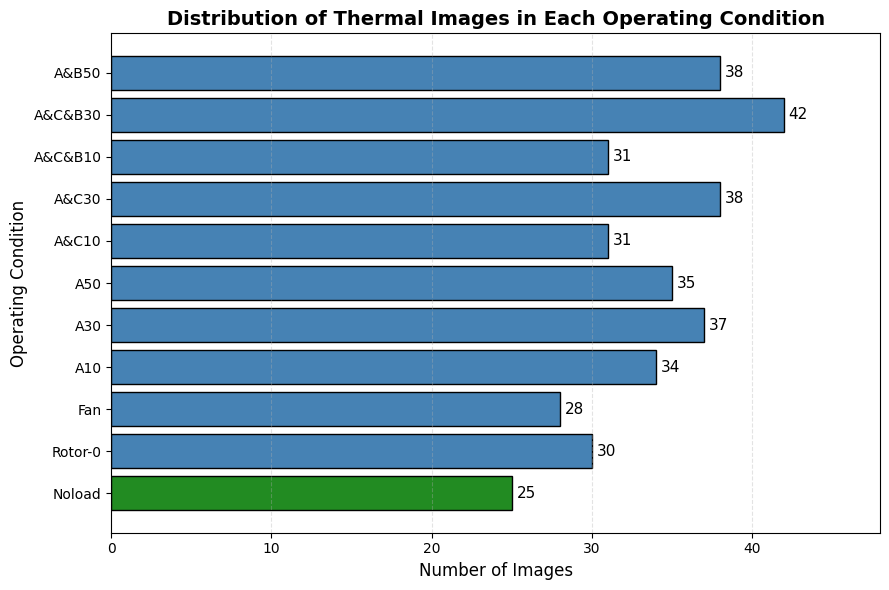

In [ ]:
import matplotlib.pyplot as plt

# เรียงลำดับที่ต้องการแสดง
order = [
    "Noload",
    "Rotor-0",
    "Fan",
    "A10",
    "A30",
    "A50",
    "A&C10",
    "A&C30",
    "A&C&B10",
    "A&C&B30",
    "A&B50"
]

# เรียงข้อมูลใหม่
plot_df = (
    df_count.set_index("Folder")
            .loc[order]
            .reset_index()
)

# กำหนดสี
colors = [
    "forestgreen" if x == "Noload" else "steelblue"
    for x in plot_df["Folder"]
]

# Plot
plt.figure(figsize=(9,6))

bars = plt.barh(
    plot_df["Folder"],
    plot_df["Images"],
    color=colors,
    edgecolor="black",
    linewidth=1
)

# ใส่ค่าบนแท่งกราฟ
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        fontsize=11
    )

plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Operating Condition", fontsize=12)
plt.title(
    "Distribution of Thermal Images in Each Operating Condition",
    fontsize=14,
    fontweight="bold"
)

plt.xlim(0, max(plot_df["Images"]) + 6)

plt.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()

# บันทึกไฟล์
plt.savefig(
    "Figure5_Class_Distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Phase 3 : ตรวจสอบคุณภาพของรูปภาพ (Image Integrity Check)

อันนี้สำคัญมาก

เราจะตรวจว่า

มีภาพเสียหรือไม่
ทุกภาพเปิดได้หรือไม่
Resolution เท่ากันหรือไม่
Mode ของภาพเหมือนกันหรือไม่

สร้าง Cell ใหม่

In [ ]:
from PIL import Image
from pathlib import Path
import pandas as pd

IMAGE_EXTS = {".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff"}

records = []

for folder in sorted(MOTOR_DIR.iterdir()):

    if not folder.is_dir():
        continue

    for img_path in sorted(folder.iterdir()):

        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue

        try:

            with Image.open(img_path) as img:

                records.append({
                    "Folder": folder.name,
                    "File": img_path.name,
                    "Width": img.width,
                    "Height": img.height,
                    "Mode": img.mode
                })

        except Exception as e:

            records.append({
                "Folder": folder.name,
                "File": img_path.name,
                "Width": None,
                "Height": None,
                "Mode": "CORRUPTED"
            })

df_images = pd.DataFrame(records)

display(df_images.head())

,Folder,File,Width,Height,Mode
0,A&B50,291.bmp,320,240,RGB
1,A&B50,292.bmp,320,240,RGB
2,A&B50,293.bmp,320,240,RGB
3,A&B50,294.bmp,320,240,RGB
4,A&B50,295.bmp,320,240,RGB


In [ ]:
print("Total images :", len(df_images))

print("\nImage Mode")
display(df_images["Mode"].value_counts())

print("\nResolution")
display(
    df_images.groupby(
        ["Width","Height"]
    ).size().reset_index(name="Count")
)

Total images : 369

Image Mode


,count
Mode,
RGB,369



Resolution


,Width,Height,Count
0,320,240,369


| รายการ            | ผลการตรวจ          |
| ----------------- | ------------------ |
| จำนวนภาพ          | ✅ 369              |
| Resolution        | ✅ 320 × 240 ทุกภาพ |
| Color Mode        | ✅ RGB ทุกภาพ       |
| Corrupted Images  | ✅ ไม่พบ            |
| ขนาดภาพไม่เท่ากัน | ✅ ไม่พบ            |


ตอนนี้เราเหลืออีก 4 ขั้นก่อนเริ่ม Train

ผมแนะนำลำดับนี้

✓ Phase 1  Dataset Path
✓ Phase 2  Folder Statistics
✓ Phase 3  Image Integrity

➡ Phase 4  Duplicate Detection   (สำคัญมาก)

➡ Phase 5  Dataset Statistics

➡ Phase 6  Train/Validation/Test Split Validation

➡ Phase 7  Data Augmentation

แล้วค่อย Train

ต่อไป Phase 4 : Duplicate Detection

อันนี้ สำคัญที่สุด
Cell ที่ 1

รันอันนี้

In [ ]:
import hashlib

def md5(path):

    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_rows = []

for folder in sorted(MOTOR_DIR.iterdir()):

    if not folder.is_dir():
        continue

    for img in sorted(folder.iterdir()):

        if img.suffix.lower() not in IMAGE_EXTS:
            continue

        hash_rows.append({

            "Folder": folder.name,
            "File": img.name,
            "MD5": md5(img)

        })

df_hash = pd.DataFrame(hash_rows)

display(df_hash.head())

,Folder,File,MD5
0,A&B50,291.bmp,ae7924f77e338e4fa126923666e42525
1,A&B50,292.bmp,a74dda4a5d6ca9c69b0b15ebcc388d9c
2,A&B50,293.bmp,76c4bf1a2b988bb092ee6344e612635e
3,A&B50,294.bmp,61e779ff8322b1c6285824fc7cb41bef
4,A&B50,295.bmp,6478c3084a0eaafdc8b17ae58eb8bd1f


In [ ]:
duplicates = df_hash[df_hash.duplicated("MD5", keep=False)]

print("Duplicate Images :", len(duplicates))

display(
    duplicates.sort_values("MD5")
)

Duplicate Images : 2


,Folder,File,MD5
233,A30,152.bmp,3230503c405c7102c9bccfd9039a9450
234,A30,153.bmp,3230503c405c7102c9bccfd9039a9450


ผลการตรวจ MD5

ผลของคุณคือ

Duplicate Images : 2

และเป็น

Folder	File	MD5
A30	152.bmp	3230503c405c7102c9bccfd9039a9450
A30	153.bmp	3230503c405c7102c9bccfd9039a9450

หมายความว่า

152.bmp และ 153.bmp เป็นไฟล์เดียวกันทุกบิต (Bit-by-Bit Identical)

ไม่ใช่แค่ภาพคล้ายกัน แต่เป็นไฟล์เดียวกันจริง ๆ

ขั้นตอนต่อไป (สำคัญ)

ก่อนลบ เราต้องตรวจสอบว่า

1. เป็นภาพซ้ำจริงหรือไม่

เปิดภาพทั้งสองมาเทียบกัน

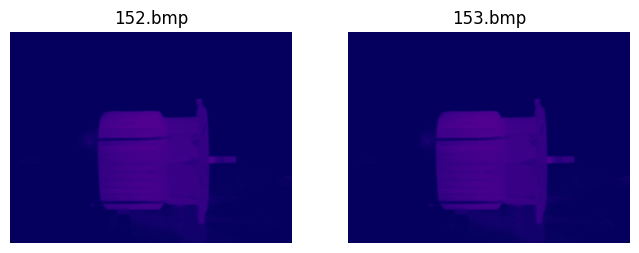

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open(MOTOR_DIR/"A30"/"152.bmp")
img2 = Image.open(MOTOR_DIR/"A30"/"153.bmp")

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("152.bmp")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("153.bmp")
plt.axis("off")

plt.show()

In [ ]:
import numpy as np
from PIL import Image

img1 = np.array(Image.open(MOTOR_DIR/"A30"/"152.bmp"))
img2 = np.array(Image.open(MOTOR_DIR/"A30"/"153.bmp"))

print("Pixel Equal :", np.array_equal(img1, img2))
print("Different Pixels :", np.sum(img1 != img2))

Pixel Equal : True
Different Pixels : 0


ยอดเยี่ยมครับ! 🎉

ตอนนี้เราสามารถ ยืนยันได้ 100% แล้วว่า

รายการ	ผล
MD5 Hash	✅ เหมือนกัน
Pixel Matrix	✅ เหมือนกัน
Different Pixels	✅ 0
ภาพที่แสดง	✅ เหมือนกัน

ดังนั้น

A30/152.bmp และ A30/153.bmp เป็นไฟล์ซ้ำ (Duplicate Image) จริง

ไม่ใช่แค่หน้าตาเหมือน แต่ข้อมูลทุกพิกเซลเหมือนกันทั้งหมด

Phase 5 : Dataset Statistics (สำคัญมาก)

นี่เป็นขั้นตอนที่หลาย Paper ระดับ Q1/Q2 ทำก่อน Train

เราจะเริ่มจาก

Step 5.1 วิเคราะห์ค่า Mean Pixel Intensity ของแต่ละ Folder

สร้าง Cell ใหม่

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image

rows = []

for folder in sorted(MOTOR_DIR.iterdir()):

    if not folder.is_dir():
        continue

    values = []

    for img_path in sorted(folder.glob("*.bmp")):

        img = np.array(Image.open(img_path)).astype(np.float32)

        # ค่าเฉลี่ยของภาพ
        values.append(img.mean())

    rows.append({

        "Folder": folder.name,
        "Images": len(values),
        "Mean Intensity": np.mean(values),
        "Std Intensity": np.std(values),
        "Min": np.min(values),
        "Max": np.max(values)

    })

df_stats = pd.DataFrame(rows)

display(df_stats.round(2))

,Folder,Images,Mean Intensity,Std Intensity,Min,Max
0,A&B50,38,69.169998,1.57,65.629997,72.290001
1,A&C&B10,31,38.590000,0.57,37.880001,40.560001
2,A&C&B30,42,61.410000,1.34,59.040001,63.889999
3,A&C10,31,34.889999,0.22,34.450001,35.480000
4,A&C30,38,45.709999,0.20,45.270000,46.110001
5,A10,34,34.459999,0.30,33.959999,35.099998
6,A30,37,39.169998,0.25,38.689999,40.099998
7,A50,35,59.970001,0.53,58.980000,61.200001
8,Fan,28,62.889999,0.86,60.980000,64.239998
9,Noload,25,40.860001,1.64,38.880001,45.509998


Step 5.2 วาดกราฟ Mean Intensity

สร้าง Cell ใหม่

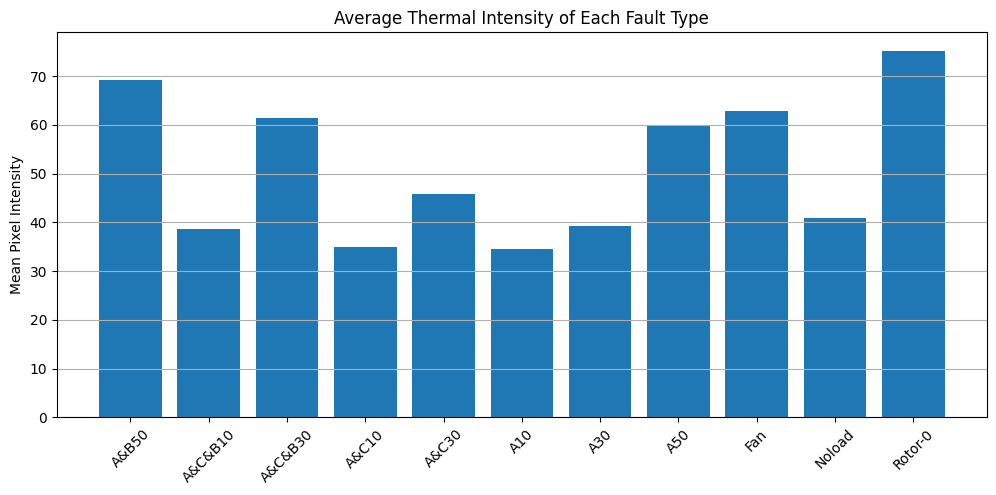

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(df_stats["Folder"], df_stats["Mean Intensity"])

plt.xticks(rotation=45)

plt.ylabel("Mean Pixel Intensity")

plt.title("Average Thermal Intensity of Each Fault Type")

plt.grid(axis="y")

plt.show()

Figure 6 Mean Thermal Intensity (Mean ± SD)

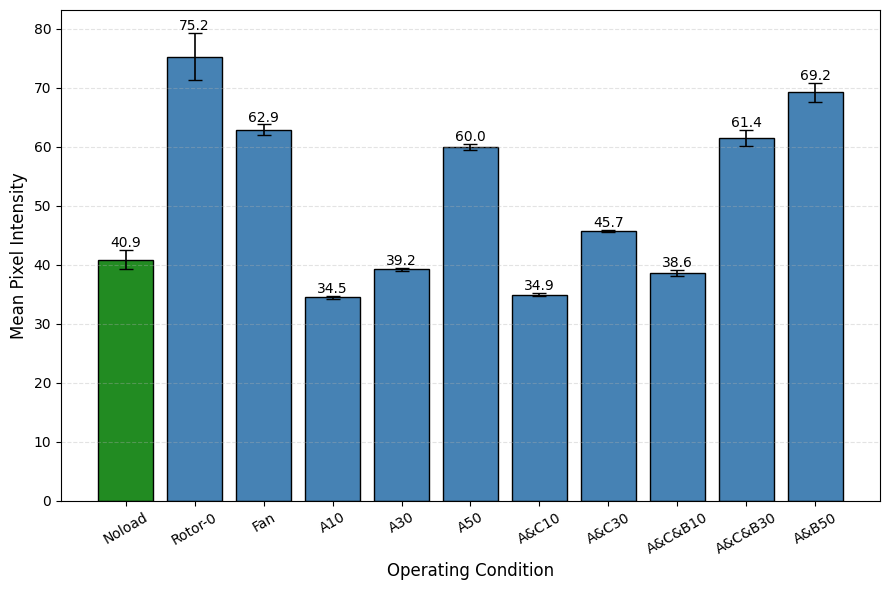

In [ ]:
import matplotlib.pyplot as plt

# เรียงลำดับเหมือน Figure 5
order = [
    "Noload",
    "Rotor-0",
    "Fan",
    "A10",
    "A30",
    "A50",
    "A&C10",
    "A&C30",
    "A&C&B10",
    "A&C&B30",
    "A&B50"
]

plot_df = (
    df_stats.set_index("Folder")
            .loc[order]
            .reset_index()
)

# สี
colors = [
    "forestgreen" if x == "Noload" else "steelblue"
    for x in plot_df["Folder"]
]

plt.figure(figsize=(9,6))

plt.bar(
    plot_df["Folder"],
    plot_df["Mean Intensity"],
    yerr=plot_df["Std Intensity"],
    capsize=5,
    color=colors,
    edgecolor="black",
    linewidth=1,
    error_kw=dict(ecolor='black', lw=1.2)
)

# แสดงค่า Mean บนแท่ง
for i, value in enumerate(plot_df["Mean Intensity"]):
    plt.text(
        i,
        value + plot_df["Std Intensity"].iloc[i] + 0.5,
        f"{value:.1f}",
        ha='center',
        fontsize=10
    )

plt.ylabel("Mean Pixel Intensity", fontsize=12)
plt.xlabel("Operating Condition", fontsize=12)

plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()

plt.savefig(
    "Figure6_Mean_Thermal_Intensity.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Step 5.3 Boxplot

อันนี้สำคัญกว่า Mean

เพราะจะเห็นการกระจาย

/tmp/ipykernel_1175/3268737503.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(folder_data, labels=labels)


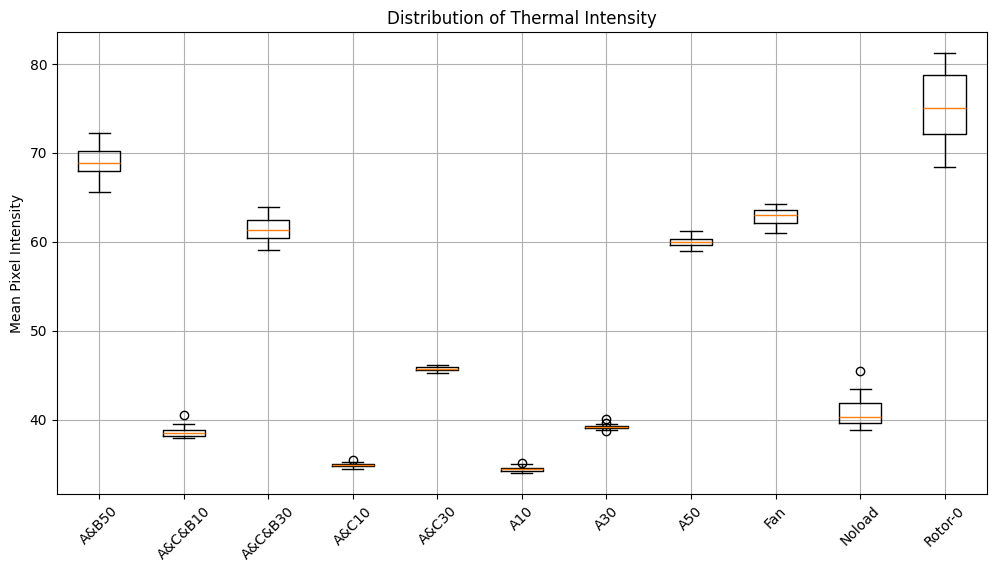

In [ ]:
folder_data = []

labels = []

for folder in sorted(MOTOR_DIR.iterdir()):

    if not folder.is_dir():
        continue

    temp = []

    for img_path in folder.glob("*.bmp"):

        img = np.array(Image.open(img_path)).astype(np.float32)

        temp.append(img.mean())

    folder_data.append(temp)
    labels.append(folder.name)

plt.figure(figsize=(12,6))

plt.boxplot(folder_data, labels=labels)

plt.xticks(rotation=45)

plt.ylabel("Mean Pixel Intensity")

plt.title("Distribution of Thermal Intensity")

plt.grid()

plt.show()

Phase 6 : PCA Analysis

เราจะดูว่า

Dataset มีการแยกกันเองหรือไม่

ถ้า PCA แยกได้

CNN ก็ควรแยกได้

ถ้า PCA ยังซ้อนกัน

CNN ก็จะยากขึ้น

Cell 1

In [ ]:
import numpy as np
from PIL import Image

X = []
y = []

for folder in sorted(MOTOR_DIR.iterdir()):

    if not folder.is_dir():
        continue

    for img_path in sorted(folder.glob("*.bmp")):

        img = Image.open(img_path)

        img = img.resize((64,64))

        img = np.array(img).astype(np.float32)

        X.append(img.flatten())

        y.append(folder.name)

X = np.array(X)

print(X.shape)

(369, 12288)


Cell 2

ทำ PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(369, 2)


Cell 3

วาด Scatter Plot

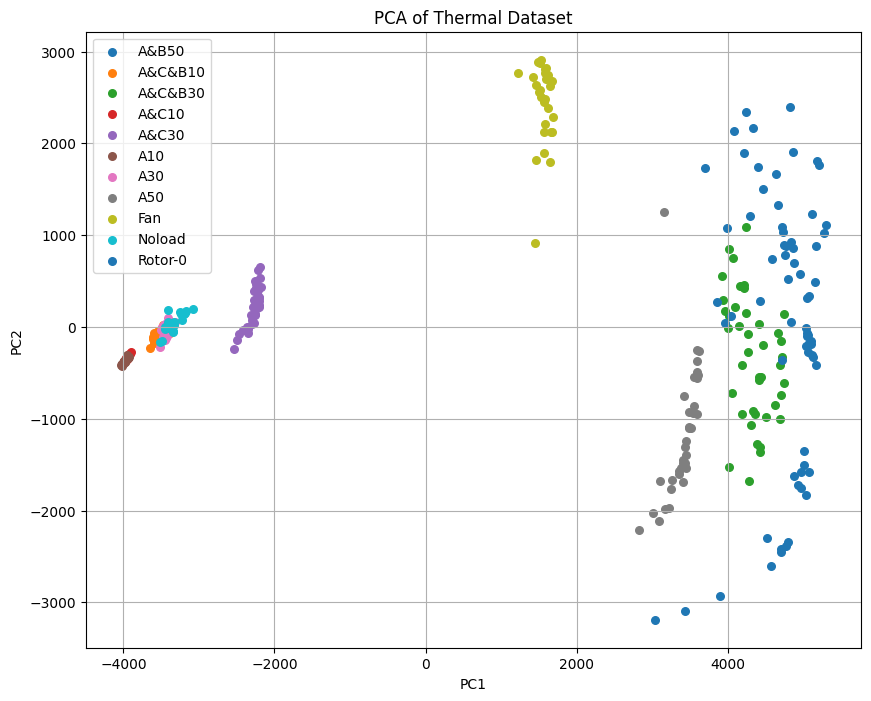

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

folders = sorted(set(y))

for folder in folders:

    idx = np.array(y) == folder

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=folder,
        s=30
    )

plt.legend()

plt.title("PCA of Thermal Dataset")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.grid()

plt.show()

⭐⭐⭐ Phase 7

ทำ

t-SNE

เพราะ

Image Dataset

นิยมใช้

มากกว่า

PCA

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X)

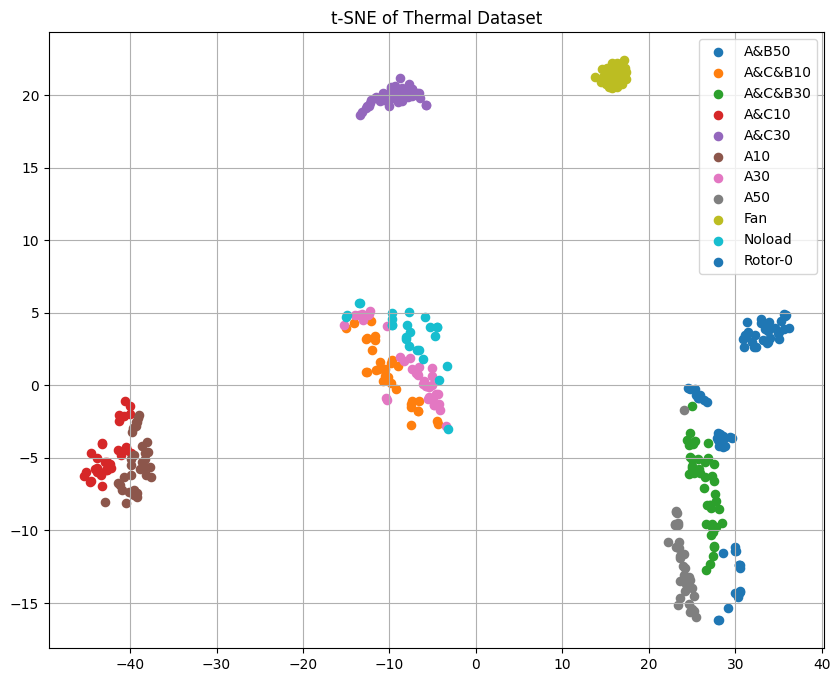

In [ ]:
plt.figure(figsize=(10,8))

folders = sorted(set(y))

for folder in folders:

    idx = np.array(y)==folder

    plt.scatter(
        X_tsne[idx,0],
        X_tsne[idx,1],
        label=folder,
        s=35
    )

plt.legend()

plt.title("t-SNE of Thermal Dataset")

plt.grid()

plt.show()

Phase 8 : Similarity Matrix Analysis
จุดประสงค์

เราจะตอบคำถามนี้

"Fault ไหนมีลักษณะคล้าย Normal มากที่สุด?"

และ

"Fault ไหนแตกต่างจาก Normal มากที่สุด?"

ผลลัพธ์นี้จะอธิบายได้ทันทีว่า

ทำไม A10 จึงตรวจจับยาก
ทำไม Rotor ตรวจจับง่าย
ทำไม Recall ของ Normal อาจต่ำ

Step 1 : สร้าง Mean Image

สร้าง Cell ใหม่

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

mean_images = {}

for folder in sorted(MOTOR_DIR.iterdir()):

    if not folder.is_dir():
        continue

    imgs = []

    for img_path in sorted(folder.glob("*.bmp")):

        img = np.array(Image.open(img_path)).astype(np.float32)

        imgs.append(img)

    mean_images[folder.name] = np.mean(imgs, axis=0)

print("Total Mean Images :", len(mean_images))

Total Mean Images : 11


Step 2 : แสดง Mean Image

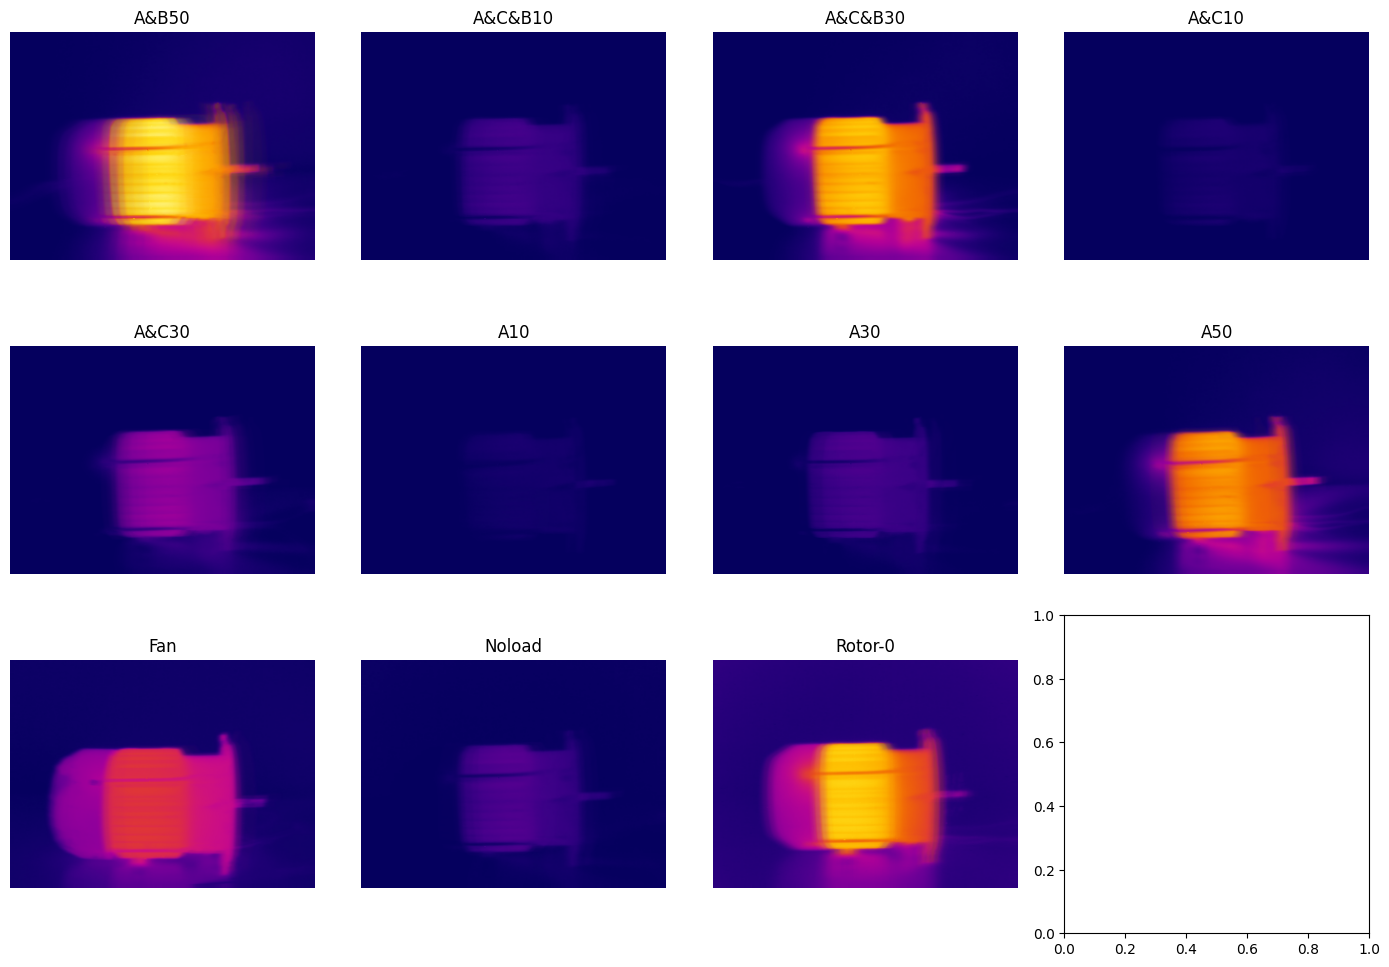

In [ ]:
fig, axes = plt.subplots(3,4, figsize=(14,10))

axes = axes.ravel()

for i,(name,img) in enumerate(mean_images.items()):

    axes[i].imshow(img.astype(np.uint8))
    axes[i].set_title(name)
    axes[i].axis("off")

plt.tight_layout()

plt.show()

Step 3 : Similarity Matrix

ใช้ SSIM

In [ ]:
from skimage.metrics import structural_similarity as ssim
import pandas as pd

folders = list(mean_images.keys())

matrix = np.zeros((len(folders),len(folders)))

for i,f1 in enumerate(folders):

    img1 = mean_images[f1].astype(np.uint8)

    img1 = np.mean(img1,axis=2)

    for j,f2 in enumerate(folders):

        img2 = mean_images[f2].astype(np.uint8)

        img2 = np.mean(img2,axis=2)

        score,_ = ssim(
            img1,
            img2,
            full=True,
            data_range=255 # Added data_range parameter
        )

        matrix[i,j]=score

df_ssim = pd.DataFrame(
    matrix,
    index=folders,
    columns=folders
)

display(df_ssim.round(3))

,A&B50,A&C&B10,A&C&B30,A&C10,A&C30,A10,A30,A50,Fan,Noload,Rotor-0
A&B50,1.000,0.816,0.952,0.773,0.864,0.766,0.820,0.926,0.863,0.828,0.856
A&C&B10,0.816,1.000,0.854,0.978,0.946,0.969,0.985,0.864,0.842,0.983,0.769
A&C&B30,0.952,0.854,1.000,0.808,0.906,0.801,0.858,0.945,0.882,0.869,0.866
A&C10,0.773,0.978,0.808,1.000,0.910,0.997,0.967,0.824,0.809,0.962,0.738
A&C30,0.864,0.946,0.906,0.910,1.000,0.905,0.952,0.929,0.858,0.965,0.832
A10,0.766,0.969,0.801,0.997,0.905,1.000,0.958,0.818,0.804,0.954,0.735
A30,0.820,0.985,0.858,0.967,0.952,0.958,1.000,0.866,0.836,0.988,0.774
A50,0.926,0.864,0.945,0.824,0.929,0.818,0.866,1.000,0.879,0.880,0.871
Fan,0.863,0.842,0.882,0.809,0.858,0.804,0.836,0.879,1.000,0.840,0.873
Noload,0.828,0.983,0.869,0.962,0.965,0.954,0.988,0.880,0.840,1.000,0.796


Step 4 : Heatmap

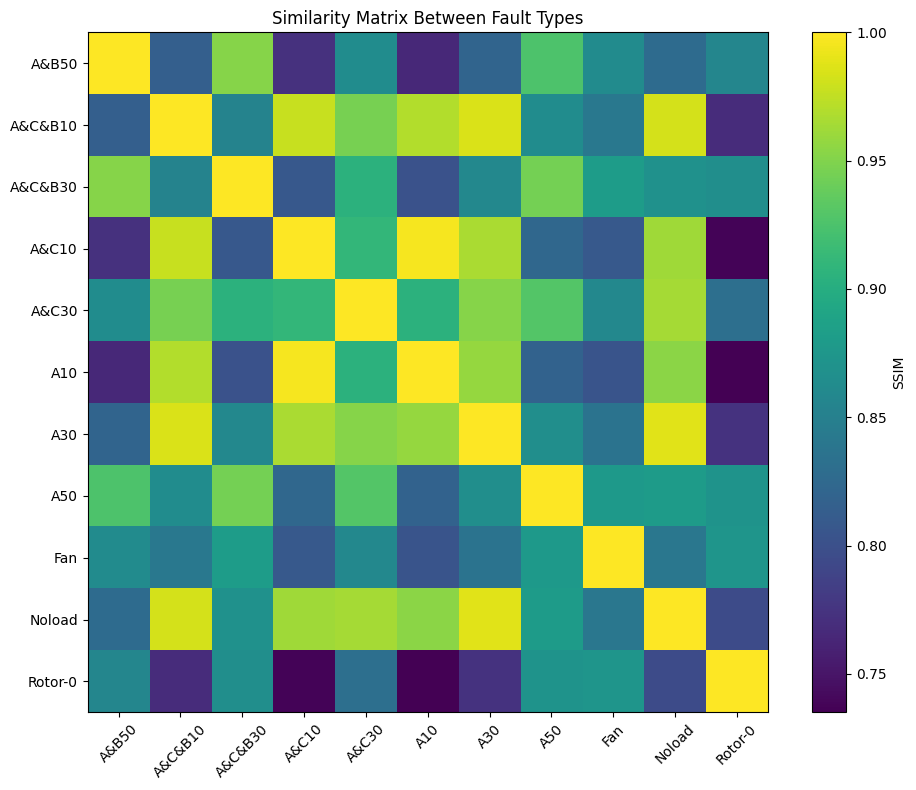

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(matrix)

plt.colorbar(label="SSIM")

plt.xticks(
    range(len(folders)),
    folders,
    rotation=45
)

plt.yticks(
    range(len(folders)),
    folders
)

plt.title("Similarity Matrix Between Fault Types")

plt.tight_layout()

plt.show()

จากนี้เข้าสู่ส่วนที่สำคัญที่สุดของงานวิจัย
🚀 Phase 9 : Training Pipeline Optimization

ผมไม่อยากใช้โค้ดเดิมแล้ว เพราะตอนนี้เราเข้าใจ Dataset ดีขึ้นมาก

ผมจะแนะนำให้สร้าง Pipeline ใหม่ทั้งหมด โดยประกอบด้วย

1. Stratified Train / Validation / Test Split (ป้องกันการกระจายคลาสไม่สมดุล)
2. Data Augmentation สำหรับ Thermal Images (เหมาะกับข้อมูลของคุณ ไม่รุนแรงเกินไป)
3. Class Weight (แก้ Slight Class Imbalance)
4. EfficientNetB0 + Transfer Learning
5. EarlyStopping + ReduceLROnPlateau + ModelCheckpoint
6. 100 Epoch พร้อม Early Stopping (เทรนได้เต็มที่แต่หยุดอัตโนมัติเมื่อไม่พัฒนา)
7. Evaluation ครบทุกตัวชี้วัด ได้แก่ Accuracy, Precision, Recall, F1-score, ROC-AUC, PR Curve, Confusion Matrix และ Learning Curves

ผมเชื่อว่าการสร้าง Pipeline ใหม่ตั้งแต่ต้นจะทำให้ผลลัพธ์มีความน่าเชื่อถือกว่าการแก้โค้ดเดิมทีละส่วน และเหมาะสำหรับนำไปใช้สร้างผลการทดลองในบทความวิจัยของคุณโดยตรงครับ

สถานะตอนนี้คือ Dataset เดิม 369 ภาพ พบ duplicate 1 คู่ ดังนั้นเป้าหมายแรกคือเตรียมข้อมูล 368 ภาพที่ไม่ซ้ำกัน แล้วค่อยแบ่ง Train/Validation/Test ก่อนทำ augmentation

วันนี้เริ่ม Step 1: สร้าง Clean Dataset Index

เรา ไม่ต้องลบไฟล์ 153.bmp ออกจาก Google Drive แต่จะตัด duplicate ออกจาก DataFrame ที่ใช้ในการทดลอง เพื่อรักษาชุดข้อมูลต้นฉบับไว้

จาก Colab เดิมที่เรามี df_hash แล้ว ให้สร้าง Cell ใหม่:

In [ ]:
# ==========================================
# STEP 1: Remove exact duplicate from index
# ==========================================

df_clean = (
    df_hash
    .drop_duplicates(subset="MD5", keep="first")
    .reset_index(drop=True)
)

print("Original images :", len(df_hash))
print("Clean images    :", len(df_clean))
print("Removed         :", len(df_hash) - len(df_clean))

display(df_clean.head())

Original images : 369
Clean images    : 368
Removed         : 1


,Folder,File,MD5
0,A&B50,291.bmp,ae7924f77e338e4fa126923666e42525
1,A&B50,292.bmp,a74dda4a5d6ca9c69b0b15ebcc388d9c
2,A&B50,293.bmp,76c4bf1a2b988bb092ee6344e612635e
3,A&B50,294.bmp,61e779ff8322b1c6285824fc7cb41bef
4,A&B50,295.bmp,6478c3084a0eaafdc8b17ae58eb8bd1f


ตรวจว่าไฟล์ใดถูกเก็บและไฟล์ใดถูกตัดออก

In [ ]:
duplicate_md5 = df_hash[
    df_hash.duplicated(subset="MD5", keep=False)
]

display(duplicate_md5.sort_values("MD5"))

,Folder,File,MD5
233,A30,152.bmp,3230503c405c7102c9bccfd9039a9450
234,A30,153.bmp,3230503c405c7102c9bccfd9039a9450


Step 1.1: เพิ่ม Binary Label

จากนั้นสร้าง Label ที่เราจะใช้จริงในการเทรน

In [ ]:
df_clean["Label"] = df_clean["Folder"].apply(
    lambda x: 0 if x == "Noload" else 1
)

df_clean["Class"] = df_clean["Label"].map({
    0: "Normal",
    1: "Abnormal"
})

display(df_clean.head())

,Folder,File,MD5,Label,Class
0,A&B50,291.bmp,ae7924f77e338e4fa126923666e42525,1,Abnormal
1,A&B50,292.bmp,a74dda4a5d6ca9c69b0b15ebcc388d9c,1,Abnormal
2,A&B50,293.bmp,76c4bf1a2b988bb092ee6344e612635e,1,Abnormal
3,A&B50,294.bmp,61e779ff8322b1c6285824fc7cb41bef,1,Abnormal
4,A&B50,295.bmp,6478c3084a0eaafdc8b17ae58eb8bd1f,1,Abnormal


ตรวจจำนวน:

In [ ]:
print("=== Binary Class Distribution ===")

print(
    df_clean["Class"]
    .value_counts()
)

print("\nTotal =", len(df_clean))

=== Binary Class Distribution ===
Class
Abnormal    343
Normal       25
Name: count, dtype: int64

Total = 368


ดังนั้นตอนนี้ Step 1: Dataset Cleaning เสร็จแล้ว และเราไม่ควรทำ Data Augmentation ตอนนี้ เพราะต้อง Split ก่อน Augmentation เพื่อป้องกัน Data Leakage

Step 2: Train / Validation / Test Split

สำหรับ Dataset ขนาดค่อนข้างเล็ก ผมเสนอ 70 : 15 : 15 และใช้ stratified split ตาม Folder (11 operating conditions) ไม่ใช่ stratify แค่ Normal/Abnormal เพราะเราต้องการให้ fault conditions ต่าง ๆ กระจายอยู่ในแต่ละชุดด้วย

สร้าง Cell ใหม่และรัน:

In [ ]:
# ==========================================
# STEP 2: Stratified Train / Val / Test Split
# Ratio = 70% / 15% / 15%
# Stratify by operating condition (Folder)
# ==========================================

from sklearn.model_selection import train_test_split

# 1) Split Train 70% and Temp 30%
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean["Folder"],
    random_state=42
)

# 2) Split Temp equally -> Validation 15%, Test 15%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Folder"],
    random_state=42
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("===== Dataset Split =====")
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))
print("Total      :", len(train_df) + len(val_df) + len(test_df))

===== Dataset Split =====
Train      : 257
Validation : 55
Test       : 56
Total      : 368


จากนั้นตรวจ Normal / Abnormal

รัน Cell ต่อไปนี้:

In [ ]:
print("===== TRAIN =====")
print(train_df["Class"].value_counts())

print("\n===== VALIDATION =====")
print(val_df["Class"].value_counts())

print("\n===== TEST =====")
print(test_df["Class"].value_counts())

===== TRAIN =====
Class
Abnormal    240
Normal       17
Name: count, dtype: int64

===== VALIDATION =====
Class
Abnormal    51
Normal       4
Name: count, dtype: int64

===== TEST =====
Class
Abnormal    52
Normal       4
Name: count, dtype: int64


และที่สำคัญ ให้ตรวจทั้ง 11 conditions ด้วย:

In [ ]:
import pandas as pd

split_distribution = pd.DataFrame({
    "Total": df_clean["Folder"].value_counts(),
    "Train": train_df["Folder"].value_counts(),
    "Validation": val_df["Folder"].value_counts(),
    "Test": test_df["Folder"].value_counts()
}).fillna(0).astype(int)

display(split_distribution)

,Total,Train,Validation,Test
Folder,,,,
A&B50,38,27,5,6
A&C&B10,31,22,5,4
A&C&B30,42,29,6,7
A&C10,31,22,5,4
A&C30,38,26,6,6
A10,34,24,5,5
A30,36,25,5,6
A50,35,24,5,6
Fan,28,20,4,4


ผลนี้ ดีครับ และผ่าน Step 2 ได้เลย การกระจายของทั้ง 11 operating conditions อยู่ในสัดส่วนใกล้เคียง 70:15:15 และที่สำคัญทุก condition ปรากฏอยู่ใน Train, Validation และ Test ครบ

ตัวอย่างเช่น Noload มี 25 ภาพ → 17/4/4 และ A&C&B30 ซึ่งมีมากที่สุด 42 ภาพ → 29/6/7 จึงไม่มีคลาสใดหายไปจากชุดประเมินผล

ก่อนทำ Data Augmentation ผมอยากเพิ่ม Step 3: Data Leakage Check อีกขั้น เพราะเป็นประเด็นสำคัญมากสำหรับงานวิจัย โดยเฉพาะ dataset ขนาดเล็กแบบนี้

Step 3 — ตรวจ Data Leakage

เนื่องจากเรามี MD5 ของทุกภาพอยู่แล้ว สามารถตรวจได้ตรง ๆ ว่ามีไฟล์เดียวกันหลุดข้าม Train/Validation/Test หรือไม่

สร้าง Cell ใหม่:

In [ ]:
# ==========================================
# STEP 3: Data Leakage Check
# ==========================================

train_hash = set(train_df["MD5"])
val_hash   = set(val_df["MD5"])
test_hash  = set(test_df["MD5"])

train_val_overlap  = train_hash.intersection(val_hash)
train_test_overlap = train_hash.intersection(test_hash)
val_test_overlap   = val_hash.intersection(test_hash)

print("===== Data Leakage Check =====")
print("Train ↔ Validation :", len(train_val_overlap))
print("Train ↔ Test       :", len(train_test_overlap))
print("Validation ↔ Test  :", len(val_test_overlap))

if (
    len(train_val_overlap) == 0 and
    len(train_test_overlap) == 0 and
    len(val_test_overlap) == 0
):
    print("\n✓ No exact-image leakage detected.")
else:
    print("\n⚠ Data leakage detected!")

===== Data Leakage Check =====
Train ↔ Validation : 0
Train ↔ Test       : 0
Validation ↔ Test  : 0

✓ No exact-image leakage detected.


ถ้าได้ 0, 0, 0 เราจะถือว่า exact duplicate leakage ผ่านครับ

อย่างไรก็ตาม MD5 ตรวจได้เฉพาะภาพที่เหมือนกันทุก pixel เท่านั้น ยังไม่ตรวจ near-duplicate เช่น ภาพมอเตอร์เฟรมติดกันที่เกือบเหมือนกัน ซึ่ง Dataset ของเรามีลักษณะดังกล่าวอยู่พอสมควร จากภาพที่เราตรวจไปก่อนหน้านี้ ประเด็นนี้ต้องระวังในการตีความผลการทดลองด้วย

รัน Cell นี้แล้วส่งผลมาให้ผมครับ ถ้าเป็น 0 ทั้งหมด ขั้นถัดไปเราจะเริ่ม Step 4: Data Augmentation และคราวนี้เราจะออกแบบ augmentation สำหรับ thermal motor images โดยเฉพาะ ไม่ใช้ augmentation ทั่วไปแบบสุ่มทั้งหมด

ผ่านครับ ผลออกมาถูกต้องทั้งหมด:

Train ↔ Validation = 0, Train ↔ Test = 0, Validation ↔ Test = 0 ดังนั้นไม่พบ exact-image leakage หลังจากลบ duplicate และแบ่งข้อมูลแล้ว

ตอนนี้ Pipeline ของเราเป็น:

369 images → Remove duplicate → 368 images → Stratified Split 70:15:15 → Leakage Check ✓

ขั้นต่อไปคือ Step 4: Data Augmentation และจุดนี้สำคัญมาก เพราะเรามี Normal ใน Training เพียง 17 ภาพ เทียบกับ Abnormal จำนวนมาก เราจึงต้องตัดสินใจก่อนว่า augmentation จะใช้เพื่อเพิ่มความหลากหลายทั่วไป หรือใช้ช่วยแก้ class imbalance ด้วย

ผมเสนอว่า อย่าเพิ่งสร้างภาพ Normal เพิ่มจนเท่ากับ Abnormal เพราะอาจทำให้โมเดลเห็นภาพที่ดัดแปลงจากต้นฉบับ 17 ภาพซ้ำมากเกินไปและเกิด overfitting ได้

แนวทางที่เหมาะกว่าคือ:

Data Augmentation (Train only) + Class Weight + Early Stopping

และ Validation/Test ห้าม augmentation โดยเด็ดขาด

สำหรับ thermal motor images ของเราจะพิจารณาอย่างระมัดระวังว่า RandomRotation, RandomZoom, RandomTranslation และ RandomContrast ตัวไหนเหมาะสม โดยเฉพาะ RandomFlip และการเปลี่ยน brightness ผมยังไม่อยากใส่ทันที เพราะอาจเปลี่ยนความหมายทางกายภาพของ thermal pattern

ดังนั้น Step 4 ต่อไป ผมจะให้โค้ด Data Augmentation พร้อมอธิบายทีละ parameter ว่าทำไมถึงเลือกค่านั้น ก่อนเริ่ม MobileNetV2 ครับ

ได้ครับ ต่อไปเป็น Step 4: Data Augmentation สำหรับภาพความร้อนของมอเตอร์ โดยผมแนะนำให้ใช้แบบ Online Augmentation และใช้เฉพาะชุด Train เท่านั้น

จากลักษณะภาพของเรา มอเตอร์อยู่ตำแหน่งค่อนข้างคงที่และ thermal pattern มีความหมายทางกายภาพ ดังนั้นควรใช้ augmentation แบบอ่อน ไม่รุนแรงเกินไป

In [ ]:
# ==========================================
# STEP 4: Data Augmentation (Train only)
# ==========================================

import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor=0.03,      # ประมาณ ±10.8 องศา
        fill_mode="reflect"
    ),

    tf.keras.layers.RandomZoom(
        height_factor=(-0.05, 0.05),
        width_factor=(-0.05, 0.05),
        fill_mode="reflect"
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.03,
        width_factor=0.03,
        fill_mode="reflect"
    ),

], name="thermal_data_augmentation")

ผม ยังไม่ใส่ RandomFlip และ RandomBrightness ในรอบแรก เพราะ flip อาจเปลี่ยนตำแหน่งเชิงกายภาพของส่วนประกอบมอเตอร์ และ brightness/contrast อาจเปลี่ยนความสัมพันธ์ของ thermal pattern ที่เราต้องการให้โมเดลเรียนรู้

Step 4.1 ตรวจภาพ Augmentation ก่อนใช้จริง

สำคัญมากครับ ต้องดูด้วยตาว่าภาพหลัง augmentation ยังสมจริงหรือไม่

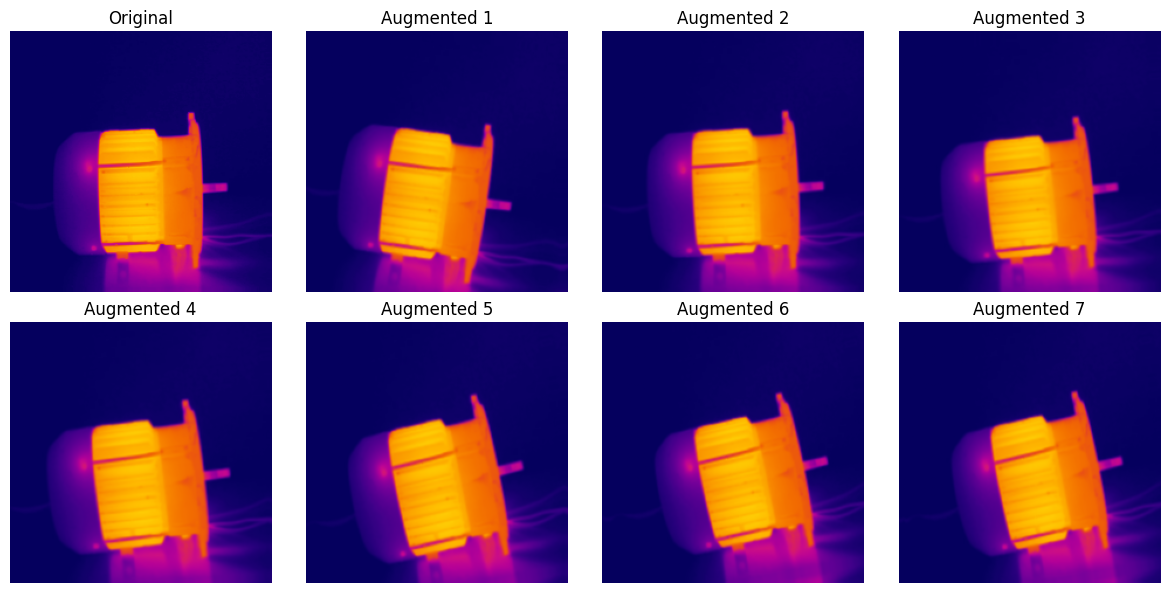

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# เลือกตัวอย่างจาก Train
sample_path = train_df.iloc[0]["Folder"]
sample_file = train_df.iloc[0]["File"]

img_path = MOTOR_DIR / sample_path / sample_file

img = Image.open(img_path).convert("RGB")
img = img.resize((224, 224))

img_array = np.array(img).astype(np.float32) / 255.0
img_tensor = tf.expand_dims(img_array, axis=0)

plt.figure(figsize=(12, 6))

# Original
plt.subplot(2, 4, 1)
plt.imshow(img_array)
plt.title("Original")
plt.axis("off")

# Augmented examples
for i in range(7):
    aug_img = data_augmentation(
        img_tensor,
        training=True
    )[0]

    plt.subplot(2, 4, i + 2)
    plt.imshow(tf.clip_by_value(aug_img, 0, 1))
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

สิ่งที่ต้องตรวจคือมอเตอร์ต้องยังอยู่ในกรอบ ไม่เอียงมากผิดธรรมชาติ ไม่ถูก crop จนเสียบริเวณสำคัญ และ hotspot ต้องไม่ถูกเปลี่ยนสีหรือความเข้มโดยตรง

ถ้าภาพออกมาสมเหตุสมผล เราจะถือว่า Step 4 ผ่าน

จากนั้นขั้นต่อไปคือ Step 5: สร้าง tf.data.Dataset สำหรับ Train / Validation / Test โดย Train จะมี augmentation ส่วน Validation และ Test จะมีเพียง resize + normalization เท่านั้น แล้วค่อยเข้าสู่ Simple CNN เป็นโมเดล baseline ครับ

ครับ ผล Data Augmentation ชุดนี้ใช้ได้ และผมแนะนำให้ล็อก configuration นี้ไว้สำหรับการทดลองหลัก

จากภาพ Original เทียบกับ Augmented 1–7 เห็นว่า rotation, zoom และ translation ทำให้ตำแหน่ง/มุมมองเปลี่ยนในระดับพอเหมาะ ขณะที่ โครงสร้างมอเตอร์และบริเวณ thermal hotspot หลักยังคงอยู่ ไม่มีภาพใดบิดเบี้ยวรุนแรงหรือ crop ส่วนสำคัญออกไป

ดังนั้น configuration ที่ใช้จริงของเราคือ:

RandomRotation(factor=0.03)
RandomZoom((-0.05, 0.05))
RandomTranslation(0.03, 0.03)

และ ไม่ใช้ Flip / Brightness augmentation ในการทดลองหลักรอบแรก

จุดสำคัญอีกอย่างคือ นี่เป็น online augmentation ดังนั้นเราไม่จำเป็นต้องสร้างไฟล์ภาพใหม่ลง Google Drive ทุก epoch ระบบจะสุ่ม transformation ใหม่ระหว่าง training ส่วน Validation และ Test จะไม่ถูก augment

# ต่อไป Step 5 — สร้าง Dataset Pipeline

ตอนนี้เราจะสร้าง Train / Validation / Test จาก train_df, val_df, test_df ที่แบ่งไว้แล้ว แต่ก่อนเขียนโค้ดส่วนนี้ ผมอยากกำหนดให้ชัดเจนว่า ยังไม่ผูก preprocessing เข้ากับ MobileNetV2 เพราะเราจะใช้ dataset ชุดเดียวกันเปรียบเทียบ Simple CNN vs MobileNetV2 อย่างยุติธรรม

ใช้โค้ดนี้ครับ:

In [ ]:
# ==========================================
# STEP 5: Build tf.data Dataset
# ==========================================

import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_bmp(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, tf.cast(label, tf.float32)


def make_dataset(df, training=False):

    paths = [
        str(MOTOR_DIR / row["Folder"] / row["File"])
        for _, row in df.iterrows()
    ]

    labels = df["Label"].astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        # Shuffle only training data
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

print("Datasets created successfully.")

Datasets created successfully.


Step 5.1 ตรวจ Shape

รันต่อทันที:

In [ ]:
for images, labels in train_ds.take(1):

    print("Image batch shape :", images.shape)
    print("Label batch shape :", labels.shape)

    print("\nPixel range:")
    print("Min :", tf.reduce_min(images).numpy())
    print("Max :", tf.reduce_max(images).numpy())

    print("\nLabels:")
    print(labels.numpy())

Image batch shape : (16, 224, 224, 3)
Label batch shape : (16,)

Pixel range:
Min : 0.0
Max : 1.0

Labels:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


ถูกต้องครับ Step 5 ผ่านเรียบร้อย ผลที่ได้ตรงตามที่เราต้องการทั้งหมด:

Batch size = 16
Input image = 224 × 224 × 3
Label shape = (16,)
Pixel range = 0–1 ถูกต้อง
Binary label: 0 = Normal, 1 = Abnormal

ส่วนที่เห็น Batch แรกเป็น [1,1,1,...] ทั้งหมด ไม่ใช่ error ครับ เนื่องจากข้อมูล Abnormal มีสัดส่วนสูงมากและเรามีการ shuffle ดังนั้นบาง batch สามารถมีแต่ Abnormal ได้ ซึ่งยิ่งยืนยันว่าเราต้องจัดการ Class Imbalance ก่อนเทรน

ค่า Min/Max ไม่จำเป็นต้องเป็น 0 และ 1 เป๊ะ แต่ต้องอยู่ภายใน [0,1]

มีจุดหนึ่งที่ตั้งใจทำไว้

สังเกตว่าใน train_ds ผมยังไม่ได้เรียก data_augmentation

นี่ตั้งใจครับ

ผมอยากให้ augmentation เป็น ส่วนหนึ่งของโมเดล:

Input → Data Augmentation → CNN → Classification

ข้อดีคือ Validation/Test จะไม่ผ่าน augmentation โดยอัตโนมัติเมื่อ training=False และลดโอกาสเขียน pipeline ผิดจน augmentation หลุดเข้า Test set

หลังจากคุณรัน Step 5.1 แล้ว ส่งผล Shape + Pixel range มาให้ผมดูครับ

ถ้าผ่าน ขั้นต่อไปเราจะทำเรื่องสำคัญก่อนสร้าง CNN คือ Step 6: คำนวณ Class Weight จาก Train set เท่านั้น เพราะตอนนี้ Training มี Normal เพียง 17 ภาพ ซึ่งเป็น class imbalance ที่ค่อนข้างรุนแรง จากนั้นจึงสร้าง Simple CNN Baseline และเริ่ม Training รอบแรกครับ

Step 6 — คำนวณ Class Weight

เราจะคำนวณจาก Training set เท่านั้น ห้ามใช้ Validation/Test ในการคำนวณ เพราะสองชุดนั้นต้องสงวนไว้สำหรับการประเมิน

รัน Cell นี้ครับ:

In [ ]:
# ==========================================
# STEP 6: Calculate Class Weights
# Training set only
# ==========================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Labels from training set
y_train = train_df["Label"].values

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

print("===== Training Class Distribution =====")
print(train_df["Class"].value_counts())

print("\n===== Class Weights =====")
print(class_weight)

===== Training Class Distribution =====
Class
Abnormal    240
Normal       17
Name: count, dtype: int64

===== Class Weights =====
{0: 7.5588235294117645, 1: 0.5354166666666667}


จาก split ของเรา Training มีทั้งหมด 257 ภาพ โดยประมาณจะเป็น:

Abnormal : 240
Normal   : 17

ดังนั้น class weight น่าจะอยู่ประมาณ:

Normal (0)   ≈ 7.56
Abnormal (1) ≈ 0.54

นี่หมายความว่า การทำนาย Normal ผิดจะถูกลงโทษใน loss มากกว่าการทำนาย Abnormal ผิด เพื่อชดเชยจำนวน Normal ที่น้อยมาก

แต่ยังมีอีกจุดที่ต้องตรวจ

ผมอยากให้รันเพิ่มอีก Cell เพื่อยืนยันสัดส่วนจริง:

In [ ]:
# Percentage distribution in training set

train_distribution = (
    train_df["Class"]
    .value_counts()
    .to_frame("Images")
)

train_distribution["Percentage (%)"] = (
    train_distribution["Images"]
    / len(train_df)
    * 100
).round(2)

display(train_distribution)

,Images,Percentage (%)
Class,,
Abnormal,240,93.39
Normal,17,6.61


เราน่าจะเห็น Normal เพียงประมาณ 6.6% และ Abnormal ประมาณ 93.4%

ตรงนี้จะเป็นข้อมูลสำคัญมากสำหรับหัวข้อ 4.3 การพัฒนาแบบจำลอง Deep Learning เพราะเราจะสามารถเขียนอย่างมีหลักฐานว่า:

เนื่องจากชุดข้อมูลฝึกมีความไม่สมดุลระหว่างคลาส โดยข้อมูล Normal มีสัดส่วนประมาณ 6.6% ขณะที่ Abnormal มีประมาณ 93.4% ผู้วิจัยจึงประยุกต์ใช้การถ่วงน้ำหนักคลาส (class weighting) ในระหว่างการฝึกแบบจำลอง เพื่อลดอคติของแบบจำลองที่มีต่อคลาสเสียงข้างมาก

ยังไม่เริ่ม CNN ครับ รันสอง Cell นี้แล้วส่งค่า class_weight และตาราง Percentage มาให้ผมดูอีกครั้ง ถ้าถูกต้อง ขั้นต่อไปเราจะสร้าง Step 7: Simple CNN Baseline และตรงนั้นเราจะกำหนด architecture, optimizer, learning rate, epoch และ callbacks อย่างเป็นระบบก่อนกด Train ครับ

ถูกต้องครับ Step 6 ผ่านแล้ว และผลยืนยันชัดเจนว่าชุด Train มี class imbalance สูง:

Abnormal = 240 ภาพ (93.39%)
Normal = 17 ภาพ (6.61%)
อัตราส่วนประมาณ 14.1 : 1

ดังนั้นการใช้ Class Weight จำเป็น สำหรับการทดลองรอบแรก โดยค่าที่คำนวณแบบ balanced จะอยู่ประมาณ

Normal (0)   = 7.559
Abnormal (1) = 0.535

จุดนี้สำคัญมาก เพราะรอบก่อนโมเดลของเราทำนาย Abnormal เกือบทั้งหมด สาเหตุหนึ่งก็คือ class imbalance และตอนนั้น class_weight ยังไม่ได้ถูกส่งเข้า fit() จริง รอบนี้เราจะแก้ให้ถูกต้องครับ

Step 7: สร้าง Simple CNN Baseline

เราจะเริ่ม Simple CNN ก่อน MobileNetV2 เพื่อให้มี Baseline ที่ยุติธรรม และใช้ architecture ที่ไม่ซับซ้อนเกินไป

รัน Cell นี้:

In [ ]:
# ==========================================
# STEP 7: Simple CNN Baseline
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models

def build_simple_cnn():

    inputs = layers.Input(
        shape=(224, 224, 3),
        name="input_image"
    )

    # Data augmentation
    # ทำงานเฉพาะ Training mode
    x = data_augmentation(inputs)

    # CNN Block 1
    x = layers.Conv2D(
        32, (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.MaxPooling2D()(x)

    # CNN Block 2
    x = layers.Conv2D(
        64, (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.MaxPooling2D()(x)

    # CNN Block 3
    x = layers.Conv2D(
        128, (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.MaxPooling2D()(x)

    # CNN Block 4
    x = layers.Conv2D(
        256, (3, 3),
        padding="same",
        activation="relu"
    )(x)

    # ลดจำนวน parameter
    x = layers.GlobalAveragePooling2D()(x)

    # ลด overfitting
    x = layers.Dropout(0.35)(x)

    # Binary classification
    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="prediction"
    )(x)

    model = models.Model(
        inputs,
        outputs,
        name="Simple_CNN"
    )

    return model


simple_cnn = build_simple_cnn()

simple_cnn.summary()

Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ thermal_data_augmentation       │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,673 (1.48 MB)

 Trainable params: 388,673 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

ผ่านครับ Architecture ถูกต้องและจำนวนพารามิเตอร์เหมาะสมสำหรับใช้เป็น Baseline CNN โดยเฉพาะเมื่อ Dataset ของเรามีเพียง 368 ภาพ

จากผล model.summary():

Total parameters = 388,673 (~1.48 MB)
Trainable parameters = 388,673
Non-trainable = 0
ใช้ GlobalAveragePooling2D แทน Flatten ทำให้จำนวนพารามิเตอร์ไม่พุ่งสูง
Output = 1 neuron + Sigmoid ถูกต้องสำหรับ Binary Classification
Data augmentation อยู่ภายในโมเดลเรียบร้อย

ดังนั้น ยังไม่ควรเพิ่ม Dense layer หรือเพิ่มความลึกของ CNN ในตอนนี้ เพราะจะเพิ่มความเสี่ยง overfitting โดยไม่จำเป็น

โครงสร้างคือ

224×224×3 → Augmentation → Conv32 → Pool → Conv64 → Pool → Conv128 → Pool → Conv256 → GAP → Dropout → Sigmoid

เป็น architecture ที่เหมาะจะใช้เป็น baseline เพราะไม่ซับซ้อนจนไปแข่งขันกับ MobileNetV2 ด้วยจำนวนพารามิเตอร์ที่มากเกินไป

Step 7.1: Compile Model

รอบนี้ผมอยากเพิ่ม metric ให้ครบกว่าของเดิมตั้งแต่การฝึก

In [ ]:
# ==========================================
# STEP 7.1: Compile Simple CNN
# ==========================================

simple_cnn.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

ตรงนี้ precision และ recall ยังหมายถึง positive class คือ Abnormal = 1 ส่วน Macro F1, Balanced Accuracy, MCC และ Normal Recall เราจะคำนวณจาก Test set ภายหลังด้วย sklearn ซึ่งถูกต้องกว่า

**Step 7.2: Callbacks**

ครั้งนี้เราไม่กำหนดว่าโมเดลต้องฝึกแค่ 30 หรือ 40 epochs แต่จะให้ maximum = 100 epochs แล้วให้ EarlyStopping ตัดสินใจ

In [ ]:
# ==========================================
# STEP 7.2: Training Callbacks
# ==========================================

callbacks_cnn = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=10,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_simple_cnn.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )
]

ทำไมใช้ 100 Epoch?

ไม่ได้หมายความว่าเราต้องฝึกครบ 100 รอบครับ

เช่น หากดีที่สุดที่ epoch 27 แล้ว val_loss ไม่ดีขึ้นอีก 10 รอบ ระบบอาจหยุดที่ epoch 37 และคืน weight จาก epoch 27 กลับมา

ดังนั้นใน Paper เราจะรายงานทั้ง

Maximum epochs = 100
Early stopping patience = 10
Best epoch = ผลจริงที่ได้จากการฝึก

วิธีนี้มีเหตุผลมากกว่ากำหนด 8 หรือ 40 epochs แบบตายตัว

# Step 8 — เริ่ม Training Simple CNN

ก่อนรัน fit() ขอให้แน่ใจว่าได้รัน Cell compile และ callbacks_cnn ที่เราเตรียมไว้แล้ว จากนั้นใช้:

In [ ]:
# ==========================================
# STEP 8: Train Simple CNN
# ==========================================

EPOCHS = 100

history_cnn = simple_cnn.fit(
    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    class_weight=class_weight,

    callbacks=callbacks_cnn,

    verbose=1
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6182 - loss: 0.7693 - pr_auc: 0.8908 - precision: 0.9253 - recall: 0.6414 - roc_auc: 0.4773
Epoch 1: val_loss improved from None to 0.66901, saving model to best_simple_cnn.keras

Epoch 1: finished saving model to best_simple_cnn.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.5681 - loss: 0.6902 - pr_auc: 0.9582 - precision: 0.9574 - recall: 0.5625 - roc_auc: 0.6249 - val_accuracy: 0.6364 - val_loss: 0.6690 - val_pr_auc: 0.9830 - val_precision: 0.8974 - val_recall: 0.6863 - val_roc_auc: 0.8039 - learning_rate: 1.0000e-04
Epoch 2/100
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8489 - loss: 0.6370 - pr_auc: 0.9829 - precision: 0.9353 - recall: 0.9016 - roc_auc: 0.7136
Epoch 2: val_loss improved from 0.66901 to 0.58545, saving model to best_simple_cnn.keras

Epoch 2: finished saving model to best_simple_cnn.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8794 - loss: 0.6726 - pr_auc: 0.973

ตรงนี้ class_weight=class_weight สำคัญมาก เพราะจะชดเชย Training set ที่มี Normal เพียง 17 ภาพเทียบกับ Abnormal 240 ภาพ

เมื่อ Train เสร็จ อย่าเพิ่งรัน Test

ก่อนแตะ test_ds เราจะตรวจ Training/Validation behavior ก่อน เพื่อไม่ให้ใช้ Test set เป็นข้อมูลในการตัดสินใจปรับโมเดล

รัน Cell นี้:

In [ ]:
# ==========================================
# Training Summary
# ==========================================

import numpy as np

best_epoch = np.argmin(history_cnn.history["val_loss"]) + 1
best_val_loss = np.min(history_cnn.history["val_loss"])

print("Training stopped at epoch :",
      len(history_cnn.history["loss"]))

print("Best epoch                :",
      best_epoch)

print("Best validation loss      :",
      round(best_val_loss, 4))

print("Best validation accuracy  :",
      round(history_cnn.history["val_accuracy"][best_epoch-1], 4))

print("Best validation ROC-AUC   :",
      round(history_cnn.history["val_roc_auc"][best_epoch-1], 4))

print("Best validation PR-AUC    :",
      round(history_cnn.history["val_pr_auc"][best_epoch-1], 4))

Training stopped at epoch : 14
Best epoch                : 4
Best validation loss      : 0.3885
Best validation accuracy  : 0.6364
Best validation ROC-AUC   : 0.6373
Best validation PR-AUC    : 0.9676


แล้ว plot Learning Curves:

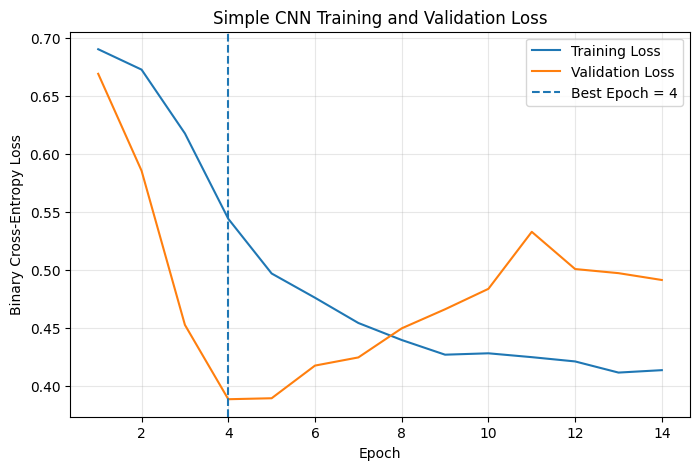

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(
    1,
    len(history_cnn.history["loss"]) + 1
)

plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    history_cnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history_cnn.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Simple CNN Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

อย่าเพิ่งกังวลว่า Accuracy ต้องสูงที่สุดครับ รอบนี้เราต้องตอบ 4 คำถามก่อน:

1. Convergence: Loss ลดลงจริงหรือไม่

2. Overfitting: Training loss ลด แต่ validation loss เริ่มเพิ่มหรือไม่

3. Best Epoch: โมเดลเหมาะสมที่สุดที่ epoch เท่าใด

4. Class imbalance: โมเดลยัง collapse ไปทำนาย Abnormal ทั้งหมดหรือไม่ — เรื่องนี้ Accuracy อย่างเดียวตอบไม่ได้

และมีจุดหนึ่งที่สำคัญมาก: Validation มี Normal เพียง 4 ภาพ ดังนั้น val_accuracy สามารถแกว่งค่อนข้างมากได้ เราจึงไม่ควรเลือกโมเดลจาก Accuracy เพียงตัวเดียว การ monitor val_loss ที่เราตั้งไว้เหมาะสมกว่าครับ

ตอนนี้กด Train ได้เลยครับ เมื่อเสร็จแล้วส่งมาให้ผมเพียง Training Summary + กราฟ Loss ก่อน ยังไม่ต้องทำ Confusion Matrix หรือ Test Evaluation แล้วเราจะวิเคราะห์ผลรอบแรกก่อนตัดสินใจว่าจะต้องปรับ CNN หรือพร้อมไป MobileNetV2 ครับ

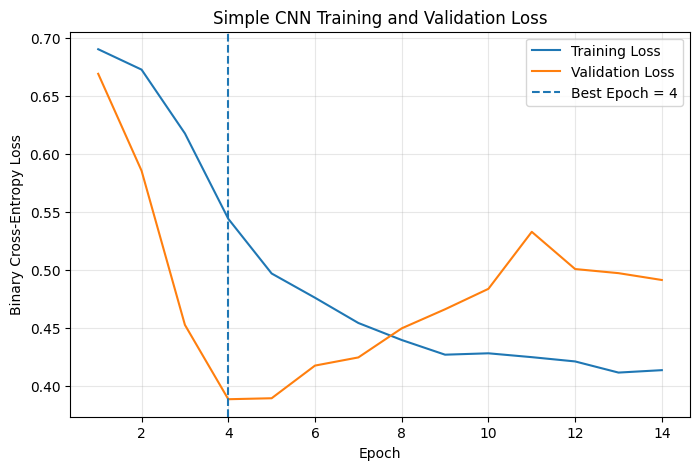
ผลรอบแรกนี้มีประโยชน์มากครับ และ Early Stopping ทำงานถูกต้อง แต่ผมยังไม่แนะนำให้ไป MobileNetV2 หรือ Test set ทันที เพราะผลนี้บอกประเด็นสำคัญเกี่ยวกับ Simple CNN ของเราได้ชัดเจน

วิเคราะห์ผล Training รอบแรก

จากกราฟ Loss เห็นว่าโมเดลเรียนรู้เร็วมากในช่วงต้น โดย validation loss ลดจากประมาณ 0.67 ลงมาเหลือค่าต่ำสุดประมาณ 0.3885 ที่ Epoch 4 หลังจากนั้น training loss ยังลดต่อ แต่ validation loss กลับเพิ่มขึ้นเรื่อย ๆ จนประมาณ 0.49 ที่ Epoch 14

ลักษณะนี้เป็น overfitting หลังประมาณ Epoch 4–5 อย่างค่อนข้างชัดเจน

จึงถือว่า Early Stopping ทำงานได้ถูกต้อง:

Best epoch = 4
Best validation loss ≈ 0.3885
Training stopped = Epoch 14
Restore weights = Epoch 4

ดังนั้นคำถามก่อนหน้านี้ว่า 100 epochs น้อยเกินไปหรือไม่? ตอนนี้ตอบได้แล้วว่า ไม่น้อยครับ และจริง ๆ โมเดลไม่จำเป็นต้อง train ถึง 100 epochs เพราะข้อมูลชุดนี้ convergence เร็วมาก การกำหนด epochs=100 เป็นเพียงเพดานสูงสุด แล้วให้ Early Stopping เป็นตัวหาจุดหยุดที่เหมาะสม ถือเป็นวิธีที่ถูกต้องกว่าเลือกจำนวน epoch แบบตายตัว

อย่างไรก็ตาม มีอีกจุดที่น่าสนใจมาก จาก Epoch 14 เราเห็นประมาณว่า accuracy = 0.638, precision = 1.000, recall = 0.6125 ขณะที่ PR-AUC ≈ 0.9895 และ ROC-AUC ≈ 0.864 ตัวเลขเหล่านี้ดูไม่สอดคล้องกันถ้ามองเฉพาะ accuracy ซึ่งเป็นผลจาก class imbalance ที่รุนแรงมาก (Abnormal 240 : Normal 17 ใน training set) และ threshold 0.5 ด้วย ดังนั้นเราไม่ควรสรุปว่าโมเดลไม่ดีจาก accuracy 63.8% เพียงอย่างเดียว

ที่สำคัญ น้ำหนักโมเดลที่เราใช้จริง ไม่ใช่ Epoch 14 เพราะระบบ restore กลับไปที่ Epoch 4 แล้ว

**ขั้นต่อไป: ตรวจ Best Epoch ให้ครบก่อนแตะ Test set**

ผมอยากให้รันโค้ดนี้ก่อน เพื่อดึงค่าที่ Epoch 4 ออกมาทั้งหมด:

In [ ]:
# ==========================================
# STEP 9: Inspect Best Epoch
# ==========================================

import numpy as np

best_epoch = np.argmin(history_cnn.history["val_loss"])
print("Best Epoch:", best_epoch + 1)

print("\n===== Training Metrics =====")

for metric in history_cnn.history.keys():
    if not metric.startswith("val_"):
        print(
            f"{metric:15s}: "
            f"{history_cnn.history[metric][best_epoch]:.4f}"
        )

print("\n===== Validation Metrics =====")

for metric in history_cnn.history.keys():
    if metric.startswith("val_"):
        print(
            f"{metric:15s}: "
            f"{history_cnn.history[metric][best_epoch]:.4f}"
        )

Best Epoch: 4

===== Training Metrics =====
accuracy       : 0.6615
loss           : 0.5441
pr_auc         : 0.9743
precision      : 0.9274
recall         : 0.6917
roc_auc        : 0.6815
learning_rate  : 0.0001

===== Validation Metrics =====
val_accuracy   : 0.6364
val_loss       : 0.3885
val_pr_auc     : 0.9676
val_precision  : 1.0000
val_recall     : 0.6078
val_roc_auc    : 0.6373


ผมอยากเห็นโดยเฉพาะ

val_loss, val_accuracy, val_precision, val_recall, val_roc_auc และ val_pr_auc

และขอเพิ่มอีก 1 กราฟ

กราฟ Loss ที่ได้ เก็บไว้เลยครับ เพราะนี่เป็นรูปที่เหมาะมากสำหรับหัวข้อ 4.3 การพัฒนาแบบจำลอง Deep Learning และใช้เป็นหลักฐานการเลือก Best Epoch = 4 ได้

แต่ก่อนประเมิน Test set ผมอยากดู ROC-AUC และ PR-AUC ระหว่าง training/validation อีกหนึ่งครั้ง:

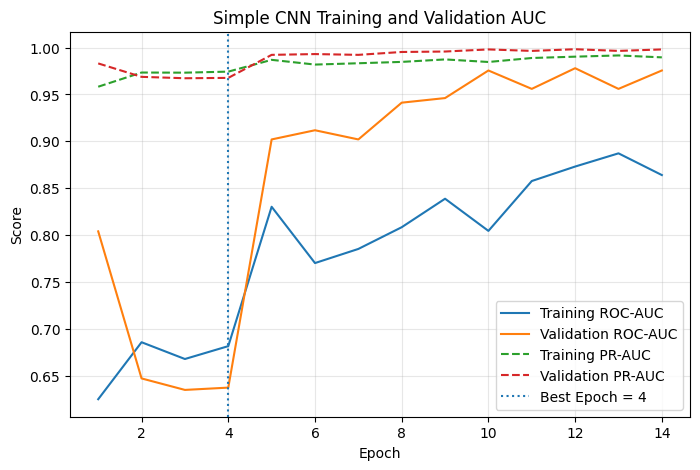

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_cnn.history["loss"]) + 1)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history_cnn.history["roc_auc"],
    label="Training ROC-AUC"
)

plt.plot(
    epochs,
    history_cnn.history["val_roc_auc"],
    label="Validation ROC-AUC"
)

plt.plot(
    epochs,
    history_cnn.history["pr_auc"],
    linestyle="--",
    label="Training PR-AUC"
)

plt.plot(
    epochs,
    history_cnn.history["val_pr_auc"],
    linestyle="--",
    label="Validation PR-AUC"
)

plt.axvline(
    best_epoch + 1,
    linestyle=":",
    label=f"Best Epoch = {best_epoch + 1}"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Simple CNN Training and Validation AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

ครับ ผลนี้ทำให้เราเห็นพฤติกรรมของ Simple CNN ชัดขึ้น และมีประเด็นสำคัญก่อนเข้าสู่ Test set

ที่ Best Epoch = 4 ได้ผลดังนี้:

Metric	Training	Validation
Accuracy	0.6615	0.6364
Loss	0.5441	0.3885
Precision	0.9274	1.0000
Recall	0.6917	0.6078
ROC-AUC	0.6815	0.6373
PR-AUC	0.9743	0.9676

จุดที่ต้องระวังคือ PR-AUC สูงมาก แต่ ROC-AUC และ Accuracy ค่อนข้างต่ำ ซึ่งสัมพันธ์กับชุดข้อมูลที่ imbalance มาก โดย training set มี Abnormal 240 ภาพ และ Normal เพียง 17 ภาพ ดังนั้น PR-AUC ที่สูงไม่ควรถูกตีความว่าโมเดลจำแนก Normal/Abnormal ได้ดีมากโดยอัตโนมัติ

อีกประเด็นหนึ่งคือ val_precision = 1.000 แต่ val_recall = 0.6078 หมายความว่า ณ threshold ที่ใช้อยู่ โมเดลทำนาย positive ค่อนข้างระมัดระวัง—เมื่อทำนาย positive มักถูก แต่ยังพลาด positive จำนวนหนึ่ง ส่วนค่า val_ROC-AUC = 0.6373 แสดงว่าความสามารถในการแยกสองคลาสโดยรวม ณ Epoch 4 ยังอยู่ในระดับไม่สูงนัก

ส่วนกราฟ AUC ที่ส่งมานั้นน่าสนใจมาก เพราะหลัง Epoch 4 ค่า Validation ROC-AUC เพิ่มขึ้นอย่างรวดเร็ว แม้ val_loss จะแย่ลง นั่นหมายความว่า epoch ที่ดีที่สุดขึ้นอยู่กับ metric ที่เราเลือกเป็นวัตถุประสงค์ ตอนนี้ Early Stopping เลือกจาก val_loss จึงคืน Epoch 4 แต่ถ้าเป้าหมายหลักคือ discrimination ระหว่าง Normal/Abnormal จุดที่ ROC-AUC สูงสุดอาจอยู่คนละ epoch

ดังนั้น ยังไม่ควรเปลี่ยน Early Stopping ไป monitor ROC-AUC ทันที และยังไม่ควรใช้ Test set ครับ เพราะเราควรตรวจอีกเรื่องหนึ่งก่อน คือโมเดลกำลังทำนายอะไรใน Validation set จริง ๆ

ขั้นต่อไปที่ผมแนะนำ: Validation Confusion Matrix

นี่จะตอบทันทีว่า Accuracy 63.64%, Precision 1.0 และ Recall 0.6078 เกิดจากอะไร และโมเดลกำลังพลาด Normal หรือ Abnormal แบบไหน

ถ้า val_ds ของเรายังเป็น dataset เดิม ขั้นต่อไปผมจะให้ code สำหรับสร้าง Confusion Matrix + Classification Report ของ Validation set ก่อนครับ

หลังจากนั้นค่อยตัดสินอย่างมีหลักฐานว่าเราควร ปรับ threshold, class weight/loss, หรือ architecture ก่อนเข้าสู่การประเมิน Test set และเปรียบเทียบกับ Transfer Learning

ส่วนจำนวน Epoch ตอนนี้ถือว่าตอบได้ค่อนข้างชัดแล้วว่า กำหนด maximum = 100 เหมาะสม ไม่ได้น้อยเกินไป เพราะ Early Stopping เป็นผู้กำหนดจำนวน epoch ที่ใช้จริง และ Simple CNN รอบนี้หยุดเองที่ Epoch 14 โดย restore Epoch 4 ครับ

ได้ครับ ขั้นต่อไปเราจะทำ Validation Confusion Matrix + Classification Report เพื่อดูว่า Simple CNN ที่ restore กลับมาที่ Epoch 4 กำลังพลาดคลาสไหนจริง ก่อนจะไปแตะ Test set

**Step 10 — ประเมินบน Validation Set**

รัน Cell นี้ก่อน:

In [ ]:
# ==========================================
# STEP 10: Validation Evaluation
# ==========================================

import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    f1_score
)

# เก็บ y_true และ probability
y_val_true = []
y_val_prob = []

for images, labels in val_ds:
    probs = simple_cnn.predict(images, verbose=0).reshape(-1)

    y_val_prob.extend(probs)
    y_val_true.extend(labels.numpy())

y_val_true = np.array(y_val_true).astype(int)
y_val_prob = np.array(y_val_prob)

# ใช้ threshold = 0.5 ก่อน
y_val_pred = (y_val_prob >= 0.5).astype(int)

print("===== Validation Classification Report =====")
print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=["Normal", "Abnormal"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_val_true, y_val_pred))

print("\nBalanced Accuracy :",
      round(balanced_accuracy_score(y_val_true, y_val_pred), 4))

print("Macro F1          :",
      round(f1_score(
          y_val_true,
          y_val_pred,
          average="macro",
          zero_division=0
      ), 4))

print("MCC               :",
      round(matthews_corrcoef(y_val_true, y_val_pred), 4))

===== Validation Classification Report =====
              precision    recall  f1-score   support

      Normal       0.17      1.00      0.29         4
    Abnormal       1.00      0.61      0.76        51

    accuracy                           0.64        55
   macro avg       0.58      0.80      0.52        55
weighted avg       0.94      0.64      0.72        55

Confusion Matrix:
[[ 4  0]
 [20 31]]

Balanced Accuracy : 0.8039
Macro F1          : 0.5209
MCC               : 0.3183


Step 10.1 — Plot Confusion Matrix

รันต่อ:

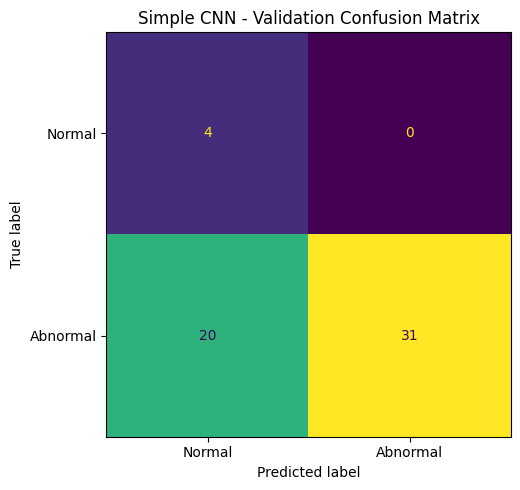

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_val_true, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abnormal"]
)

fig, ax = plt.subplots(figsize=(5.5, 5))

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title("Simple CNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

Step 10.2 — ดู Probability Distribution

ขอเพิ่มอีกกราฟหนึ่ง เพราะจะช่วยตัดสินเรื่อง Threshold ได้มากกว่า Confusion Matrix อย่างเดียว

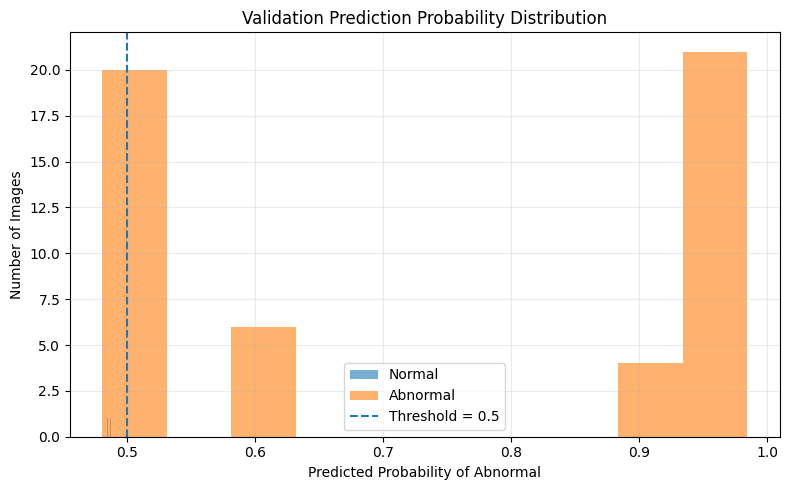

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    y_val_prob[y_val_true == 0],
    bins=10,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    y_val_prob[y_val_true == 1],
    bins=10,
    alpha=0.6,
    label="Abnormal"
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Threshold = 0.5"
)

plt.xlabel("Predicted Probability of Abnormal")
plt.ylabel("Number of Images")

plt.title("Validation Prediction Probability Distribution")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

ผลนี้สำคัญมากครับ และตอนนี้เราเห็นสาเหตุที่ **Validation Accuracy = 63.64%** ชัดเจนแล้ว

จาก Confusion Matrix:

[
\begin{bmatrix}
4 & 0\
20 & 31
\end{bmatrix}
]

หมายความว่า Normal ทั้ง 4 ภาพถูกจำแนกถูกทั้งหมด แต่ Abnormal 51 ภาพ โมเดลตรวจถูกเพียง 31 ภาพ และผิดเป็น Normal ถึง 20 ภาพ ดังนั้น **ปัญหาหลักของ Simple CNN ตอนนี้คือ False Negative สูง** ไม่ใช่การตรวจ Normal ไม่ได้

ค่าที่ได้จึงสอดคล้องกันดี: Normal recall = 1.00, Abnormal recall = 0.61, Balanced Accuracy = 0.8039, Macro F1 = 0.5209 และ MCC = 0.3183

ที่น่าสนใจมากคือกราฟ probability แสดงการแบ่ง Abnormal ออกเป็นกลุ่มค่อนข้างชัด: กลุ่มหนึ่งอยู่ประมาณ 0.48–0.62 ขณะที่อีกกลุ่มอยู่ประมาณ 0.89–0.98 ส่วน Normal มีเพียง 4 ตัวอย่าง จึงยังน้อยเกินไปที่จะสรุปเรื่อง threshold จากกราฟนี้อย่างมั่นใจ

ดังนั้น **ผมไม่แนะนำให้ลด threshold ทันที** เพราะ validation มี Normal เพียง 4 ภาพ การเลือก threshold จากข้อมูลเพียง 4 ตัวอย่างมีความเสี่ยงต่อ overfitting กับ validation set

### ข้อสรุปสำหรับ Simple CNN รอบแรก

โมเดลนี้ควรเก็บไว้เป็น **Baseline Model** ครับ ไม่ต้อง train ใหม่ในตอนนี้ ผลไม่ได้ล้มเหลว แต่กลับเป็นผลที่มีประโยชน์ต่อ paper เพราะแสดงข้อจำกัดของ CNN ที่ฝึกจาก scratch บน dataset ขนาดเล็กและ class imbalance สูงได้ชัดเจน

และ **ยังไม่ใช้ Test set** เพื่อปรับโมเดลหรือ threshold เพราะ Test set ควรเก็บไว้สำหรับการประเมินครั้งสุดท้ายเท่านั้น

ขั้นต่อไปที่เหมาะสมที่สุดคือ **พัฒนาโมเดลที่ 2 ด้วย Transfer Learning** เช่น MobileNetV2 แล้วใช้ train/validation ชุดเดิม, augmentation เดิม และ class weighting เดิม เพื่อให้เปรียบเทียบกับ Simple CNN ได้อย่างยุติธรรม จากนั้นค่อยนำโมเดลที่กำหนดวิธีเลือกไว้ล่วงหน้าไปประเมิน Test set ในหัวข้อ 4.4

สำหรับ paper ผมแนะนำให้เก็บ **Confusion Matrix รูปนี้ไว้** เพราะมีคุณค่ามากกว่ากราฟ probability distribution ส่วน Classification Report สามารถนำตัวเลขไปทำเป็นตารางผลเปรียบเทียบ Simple CNN กับโมเดลอื่นภายหลังได้ครับ

**ขั้นถัดไป:** เราจะสร้าง **MobileNetV2 Transfer Learning** โดยยังไม่เปลี่ยน dataset split เพื่อให้การทดลองควบคุมตัวแปรได้ดีครับ


ต่อไปเราจะทำ
**Step 11: MobileNetV2 Transfer Learning **

โดยใช้ชุดข้อมูลเดิม, split เดิม, augmentation เดิม และ class weight เดิมทั้งหมด เพื่อให้เปรียบเทียบกับ Simple CNN ได้อย่างยุติธรรมครับ

ผมแนะนำให้ฝึก 2 ระยะ เพราะดีกว่าการ freeze backbone ตลอดเหมือนโค้ดเดิม

**Step 11.1 — สร้าง MobileNetV2**

In [ ]:
# ==========================================
# STEP 11.1: Build MobileNetV2
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models

def build_mobilenetv2():

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Stage 1: freeze backbone
    base_model.trainable = False

    inputs = layers.Input(
        shape=(224, 224, 3),
        name="input_image"
    )

    # Augmentation เฉพาะตอน training
    x = data_augmentation(inputs)

    # train_ds ปัจจุบันอยู่ในช่วง [0,1]
    # MobileNetV2 ต้องการ [-1,1]
    x = tf.keras.applications.mobilenet_v2.preprocess_input(
        x * 255.0
    )

    x = base_model(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.35)(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="prediction"
    )(x)

    model = models.Model(
        inputs,
        outputs,
        name="MobileNetV2_binary"
    )

    return model, base_model


mobilenet, base_model = build_mobilenetv2()

mobilenet.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ thermal_data_augmentation       │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

ค่าที่ควรเห็นประมาณ:

Total params          ≈ 2.26 M
Trainable params      ≈ 1,281
Non-trainable params  ≈ 2.26 M

ตรงนี้ตั้งใจครับ เพราะ Stage 1 จะฝึกเฉพาะ classification head

Step 11.2 — Compile Stage 1

In [ ]:
# ==========================================
# STEP 11.2: Compile Stage 1
# ==========================================

mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

สังเกตว่า learning rate รอบนี้ใช้ 1e-3 ซึ่งสูงกว่า Simple CNN เพราะเราฝึกเพียง Dense head เล็ก ๆ เท่านั้น

Step 11.3 — Callbacks สำหรับ Stage 1

สร้าง callbacks ใหม่ครับ อย่าใช้ object เดิมจาก Simple CNN

In [ ]:
# ==========================================
# STEP 11.3: Stage 1 Callbacks
# ==========================================

callbacks_mobilenet_stage1 = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=8,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_mobilenet_stage1.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )
]

Step 11.4 — Train Stage 1

In [ ]:
# ==========================================
# STEP 11.4: Train Stage 1
# ==========================================

history_mobilenet_stage1 = mobilenet.fit(
    train_ds,
    validation_data=val_ds,

    epochs=30,

    class_weight=class_weight,

    callbacks=callbacks_mobilenet_stage1,

    verbose=1
)

Epoch 1/30
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5164 - loss: 0.7574 - pr_auc: 0.9521 - precision: 0.9399 - recall: 0.5401 - roc_auc: 0.3241
Epoch 1: val_loss improved from None to 0.67667, saving model to best_mobilenet_stage1.keras

Epoch 1: finished saving model to best_mobilenet_stage1.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.6887 - loss: 0.8242 - pr_auc: 0.9465 - precision: 0.9255 - recall: 0.7250 - roc_auc: 0.5217 - val_accuracy: 0.5273 - val_loss: 0.6767 - val_pr_auc: 0.9786 - val_precision: 1.0000 - val_recall: 0.4902 - val_roc_auc: 0.7696 - learning_rate: 0.0010
Epoch 2/30
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6277 - loss: 0.4775 - pr_auc: 0.9922 - precision: 1.0000 - recall: 0.6001 - roc_auc: 0.9000
Epoch 2: val_loss improved from 0.67667 to 0.42325, saving model to best_mobilenet_stage1.keras

Epoch 2: finished saving model to best_mobilenet_stage1.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6148 - loss: 0.4

เราไม่จำเป็นต้อง train ครบ 30 epochs ถ้า EarlyStopping หยุดก่อน

Step 11.5 — ดูผล Stage 1 ก่อน Fine-tuning

รัน:

In [ ]:
import numpy as np

best_epoch_stage1 = (
    np.argmin(
        history_mobilenet_stage1.history["val_loss"]
    ) + 1
)

print(
    "Stage 1 stopped at epoch :",
    len(history_mobilenet_stage1.history["loss"])
)

print(
    "Best epoch Stage 1       :",
    best_epoch_stage1
)

print(
    "Best validation loss     :",
    round(
        min(
            history_mobilenet_stage1.history["val_loss"]
        ),
        4
    )
)

print(
    "Validation accuracy      :",
    round(
        history_mobilenet_stage1.history["val_accuracy"][
            best_epoch_stage1 - 1
        ],
        4
    )
)

print(
    "Validation ROC-AUC       :",
    round(
        history_mobilenet_stage1.history["val_roc_auc"][
            best_epoch_stage1 - 1
        ],
        4
    )
)

Stage 1 stopped at epoch : 25
Best epoch Stage 1       : 17
Best validation loss     : 0.2083
Validation accuracy      : 0.8727
Validation ROC-AUC       : 1.0


จากนั้น Plot Loss:

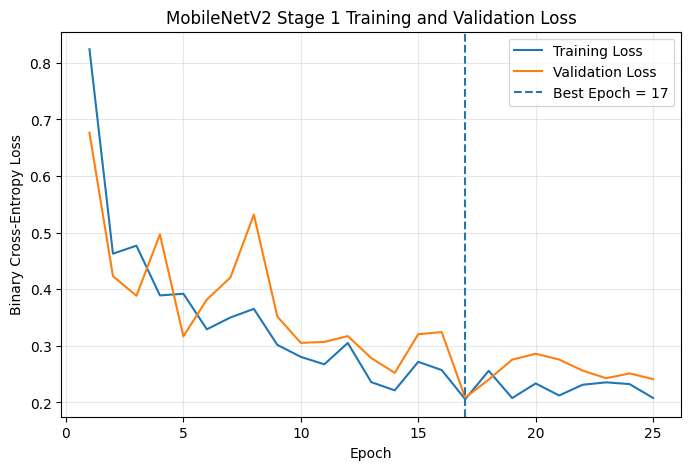

In [ ]:
import matplotlib.pyplot as plt

epochs = range(
    1,
    len(history_mobilenet_stage1.history["loss"]) + 1
)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history_mobilenet_stage1.history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_mobilenet_stage1.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch_stage1,
    linestyle="--",
    label=f"Best Epoch = {best_epoch_stage1}"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title(
    "MobileNetV2 Stage 1 Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

ดีครับ ผล MobileNetV2 Stage 1 ดีกว่า Simple CNN อย่างชัดเจน และเราสามารถไป Stage 2: Fine-tuning ต่อได้เลย

เปรียบเทียบเบื้องต้น ณ best epoch:

Model	Best Epoch	Val Loss	Val Accuracy	Val ROC-AUC
Simple CNN	4	0.3885	0.6364	0.6373
MobileNetV2 Stage 1	17	0.2083	0.8727	1.0000

ผลนี้สนับสนุนว่า pretrained features ช่วยได้มากกับ dataset ขนาดเล็กของเรา อย่างไรก็ตาม ROC-AUC = 1.0000 ยังไม่ควรสรุปว่าโมเดลสมบูรณ์ เพราะ validation set มีเพียง 55 ภาพ และ Normal เพียง 4 ภาพ เราจะตรวจ Confusion Matrix ภายหลังอีกครั้ง

กราฟ Loss ก็ดีขึ้นมาก โดย training/validation loss ลดลงในทิศทางใกล้เคียงกัน และ best epoch อยู่ที่ 17 ไม่ได้เกิด overfitting เร็วแบบ Simple CNN

Step 12 — Fine-tuning MobileNetV2

ตอนนี้ อย่าสร้าง MobileNetV2 ใหม่ เพราะเราต้อง fine-tune ต่อจากน้ำหนัก Stage 1 ที่ดีที่สุด ซึ่ง Early Stopping restore มาให้แล้ว

Step 12.1 เปิดเฉพาะ 30 Layers สุดท้าย

In [ ]:
# ==========================================
# STEP 12.1: Unfreeze last 30 layers
# ==========================================

base_model.trainable = True

# Freeze ทุก layer ก่อน
for layer in base_model.layers:
    layer.trainable = False

# เปิดเฉพาะ 30 layers สุดท้าย
for layer in base_model.layers[-30:]:
    layer.trainable = True

# สำคัญสำหรับ dataset ขนาดเล็ก:
# ให้ BatchNormalization frozen ต่อไป
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total backbone layers:",
      len(base_model.layers))

print("Trainable backbone layers:",
      sum(layer.trainable for layer in base_model.layers))

Total backbone layers: 154
Trainable backbone layers: 19


เหตุผลที่ไม่เปิดทั้งหมด เพราะ dataset เรามีเพียง 368 ภาพหลังลบ duplicate การ fine-tune มากเกินไปมีความเสี่ยง overfitting สูง

Step 12.2 Compile ใหม่ด้วย Learning Rate ต่ำ

หลังเปลี่ยน trainable ต้อง compile ใหม่:

In [ ]:
# ==========================================
# STEP 12.2: Recompile for Fine-tuning
# ==========================================

mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),

        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

ตรงนี้ 1e-5 ตั้งใจให้ต่ำกว่า Stage 1 มาก เพื่อไม่ให้น้ำหนัก pretrained เปลี่ยนรุนแรงเกินไป

Step 12.3 สร้าง Callback ใหม่

In [ ]:
# ==========================================
# STEP 12.3: Fine-tuning Callbacks
# ==========================================

callbacks_finetune = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=8,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_mobilenet_finetuned.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )
]

Step 12.4 Fine-tune

ให้ maximum 30 epochs เช่นเดิมครับ ไม่ได้หมายความว่าต้องใช้ครบ

In [ ]:
# ==========================================
# STEP 12.4: Fine-tuning
# ==========================================

history_finetune = mobilenet.fit(
    train_ds,
    validation_data=val_ds,

    epochs=30,

    class_weight=class_weight,

    callbacks=callbacks_finetune,

    verbose=1
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8876 - loss: 0.2142 - pr_auc: 0.9987 - precision: 1.0000 - recall: 0.8788 - roc_auc: 0.9817
Epoch 1: val_loss improved from None to 0.48062, saving model to best_mobilenet_finetuned.keras

Epoch 1: finished saving model to best_mobilenet_finetuned.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.8988 - loss: 0.2176 - pr_auc: 0.9985 - precision: 1.0000 - recall: 0.8917 - roc_auc: 0.9779 - val_accuracy: 0.7455 - val_loss: 0.4806 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.7255 - val_roc_auc: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/30
14/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8248 - loss: 0.2560 - pr_auc: 0.9973 - precision: 0.9996 - recall: 0.8130 - roc_auc: 0.9630
Epoch 2: val_loss improved from 0.48062 to 0.15530, saving model to best_mobilenet_finetuned.keras

Epoch 2: finished saving model to best_mobilenet_finetuned.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0

Step 12.5 หาค่า Best Epoch

In [ ]:
import numpy as np

best_epoch_ft = (
    np.argmin(history_finetune.history["val_loss"]) + 1
)

print("Fine-tuning stopped at epoch :",
      len(history_finetune.history["loss"]))

print("Best fine-tuning epoch       :",
      best_epoch_ft)

print("Best validation loss         :",
      round(
          history_finetune.history["val_loss"][best_epoch_ft-1],
          4
      ))

print("Validation accuracy          :",
      round(
          history_finetune.history["val_accuracy"][best_epoch_ft-1],
          4
      ))

print("Validation precision         :",
      round(
          history_finetune.history["val_precision"][best_epoch_ft-1],
          4
      ))

print("Validation recall            :",
      round(
          history_finetune.history["val_recall"][best_epoch_ft-1],
          4
      ))

print("Validation ROC-AUC           :",
      round(
          history_finetune.history["val_roc_auc"][best_epoch_ft-1],
          4
      ))

print("Validation PR-AUC            :",
      round(
          history_finetune.history["val_pr_auc"][best_epoch_ft-1],
          4
      ))

Fine-tuning stopped at epoch : 24
Best fine-tuning epoch       : 16
Best validation loss         : 0.0279
Validation accuracy          : 1.0
Validation precision         : 1.0
Validation recall            : 1.0
Validation ROC-AUC           : 1.0
Validation PR-AUC            : 1.0


ผล Fine-tuning ดีมากครับ และ ดีขึ้นจาก Stage 1 อย่างชัดเจน:

Trainable backbone layers = 19 จาก 154 layers
Fine-tuning หยุดที่ epoch 24
Best fine-tuning epoch = 16
Best validation loss = 0.0279
Validation accuracy = 1.000
Validation precision = 1.000
Validation recall = 1.000
Validation ROC-AUC = 1.000
Validation PR-AUC = 1.000

เมื่อเทียบกับ Stage 1 ที่ val loss = 0.2083 และ accuracy = 0.8727 ถือว่า Fine-tuning ช่วยได้มาก

อย่างไรก็ตาม ผมขอเน้นว่า ยังไม่ควรสรุปว่าโมเดลสมบูรณ์แบบ เพราะ validation set มีเพียง 55 ภาพ และ Normal มีแค่ 4 ภาพ ดังนั้นผล 100% ยังมีความไม่แน่นอนอยู่ ต้องยืนยันด้วย Test set ที่เราเก็บไว้และยังไม่เคยใช้ในการปรับโมเดล

ขั้นต่อไป: Final Test Evaluation

ตอนนี้ถือว่าเราล็อกโมเดล MobileNetV2 Fine-tuned ที่ best epoch 16 แล้ว ขั้นต่อไปสามารถใช้ test_ds ได้ครั้งแรกเพื่อประเมินผลสุดท้าย

รันโค้ดนี้:

In [ ]:
# ==========================================
# STEP 13: Final Test Evaluation
# ==========================================

import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)

y_test_true = []
y_test_prob = []

for images, labels in test_ds:
    probs = mobilenet.predict(images, verbose=0).reshape(-1)

    y_test_prob.extend(probs)
    y_test_true.extend(labels.numpy())

y_test_true = np.array(y_test_true).astype(int)
y_test_prob = np.array(y_test_prob)

# ใช้ threshold มาตรฐาน 0.5
y_test_pred = (y_test_prob >= 0.5).astype(int)

print("===== TEST CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=["Normal", "Abnormal"],
        zero_division=0
    )
)

print("===== FINAL TEST METRICS =====")

print("Accuracy          :",
      round(accuracy_score(y_test_true, y_test_pred), 4))

print("Macro Precision   :",
      round(precision_score(
          y_test_true,
          y_test_pred,
          average="macro",
          zero_division=0
      ), 4))

print("Macro Recall      :",
      round(recall_score(
          y_test_true,
          y_test_pred,
          average="macro",
          zero_division=0
      ), 4))

print("Macro F1          :",
      round(f1_score(
          y_test_true,
          y_test_pred,
          average="macro",
          zero_division=0
      ), 4))

print("Balanced Accuracy :",
      round(balanced_accuracy_score(
          y_test_true,
          y_test_pred
      ), 4))

print("MCC               :",
      round(matthews_corrcoef(
          y_test_true,
          y_test_pred
      ), 4))

print("ROC-AUC           :",
      round(roc_auc_score(
          y_test_true,
          y_test_prob
      ), 4))

print("PR-AUC            :",
      round(average_precision_score(
          y_test_true,
          y_test_prob
      ), 4))

===== TEST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Normal       0.80      1.00      0.89         4
    Abnormal       1.00      0.98      0.99        52

    accuracy                           0.98        56
   macro avg       0.90      0.99      0.94        56
weighted avg       0.99      0.98      0.98        56

===== FINAL TEST METRICS =====
Accuracy          : 0.9821
Macro Precision   : 0.9
Macro Recall      : 0.9904
Macro F1          : 0.9396
Balanced Accuracy : 0.9904
MCC               : 0.8858
ROC-AUC           : 1.0
PR-AUC            : 1.0


จากนั้นทำ Confusion Matrix:

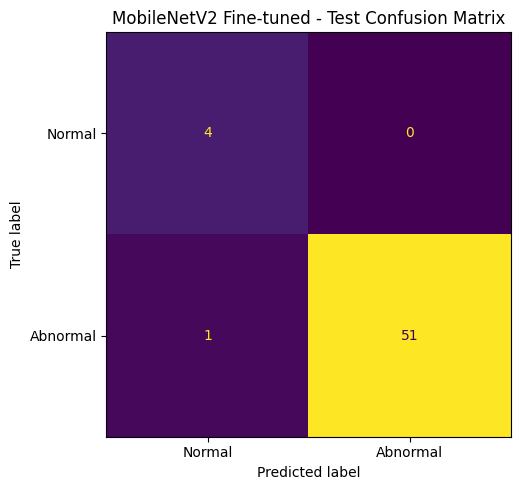

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_true,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abnormal"]
)

fig, ax = plt.subplots(figsize=(5.5,5))

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title("MobileNetV2 Fine-tuned - Test Confusion Matrix")

plt.tight_layout()
plt.show()

และ ROC + PR Curve:

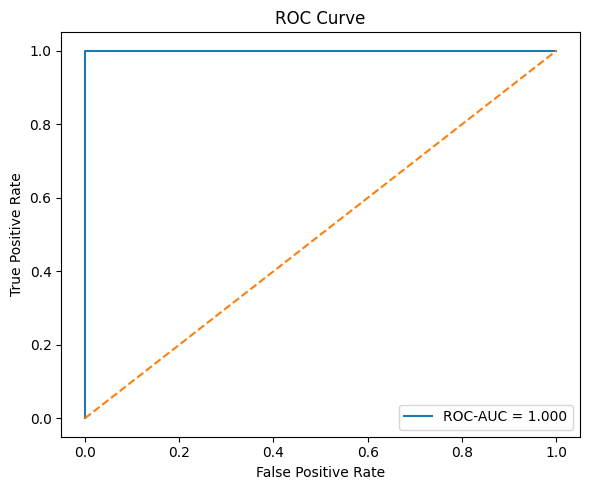

In [ ]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)

# ROC
fpr, tpr, _ = roc_curve(
    y_test_true,
    y_test_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc_score(y_test_true, y_test_prob):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

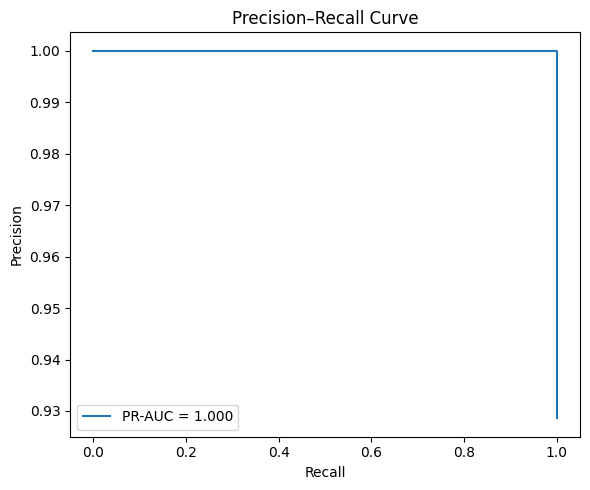

In [ ]:
# Precision–Recall
precision, recall, _ = precision_recall_curve(
    y_test_true,
    y_test_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {average_precision_score(y_test_true, y_test_prob):.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

ผล Test set ออกมาดีมาก และที่สำคัญ **น่าเชื่อถือกว่า Validation = 100%** เพราะเป็นข้อมูลที่ไม่ได้ใช้ในการปรับโมเดลครับ

จาก Test จำนวน **56 ภาพ** โมเดล MobileNetV2 หลัง Fine-tuning จำแนกถูก **55 ภาพ** และผิดเพียง **1 ภาพ** โดย Normal ทั้ง 4 ภาพจำแนกถูกทั้งหมด ส่วน Abnormal 52 ภาพ จำแนกถูก 51 ภาพ และผิดเป็น Normal 1 ภาพ ดังนั้น Confusion Matrix คือ TN=4, FP=0, FN=1 และ TP=51

ผลหลักสำหรับรายงานคือ **Accuracy = 98.21%, Macro F1 = 93.96%, Balanced Accuracy = 99.04%, MCC = 0.8858, ROC-AUC = 1.000 และ PR-AUC = 1.000** โดย Normal มี Precision = 0.80, Recall = 1.00, F1 = 0.89 ขณะที่ Abnormal มี Precision = 1.00, Recall = 0.98 และ F1 = 0.99

มีประเด็นสำคัญหนึ่งอย่าง: **ROC-AUC และ PR-AUC = 1.0 ไม่ได้ขัดกับ Accuracy = 98.21%** เพราะ AUC วัดความสามารถในการ *จัดอันดับ* probability ระหว่างสองคลาสในทุก threshold ขณะที่ Accuracy ใช้ threshold ที่กำหนดไว้ 0.5 จึงยังเกิดความผิดพลาดได้ 1 ภาพ

สำหรับ paper ผมแนะนำว่า **ไม่จำเป็นต้องใส่ ROC Curve และ PR Curve ทั้งสองรูป** เพราะพื้นที่จะเยอะเกินไป โดยเฉพาะชุดข้อมูลนี้มี class imbalance สูงมาก ผมจะเลือก **Confusion Matrix เป็นรูปหลัก** เพราะเห็นทันทีว่าโมเดลผิดตรงไหน แล้วรายงาน ROC-AUC และ PR-AUC ในตารางผลการทดลองแทน

ตารางในหัวข้อ **4.4 การประเมินประสิทธิภาพของแบบจำลอง** สามารถจัดประมาณนี้:

| Metric            | Simple CNN (Validation) | MobileNetV2 Fine-tuned (Test) |
| ----------------- | ----------------------: | ----------------------------: |
| Accuracy          |                  0.6364 |                    **0.9821** |
| Macro F1          |                  0.5209 |                    **0.9396** |
| Balanced Accuracy |                  0.8039 |                    **0.9904** |
| MCC               |                  0.3183 |                    **0.8858** |
| ROC-AUC           |                 0.6373* |                    **1.0000** |
| PR-AUC            |                 0.9676* |                    **1.0000** |

*ค่าของ Simple CNN ที่เรามีก่อนหน้านี้เป็นผลจาก validation ดังนั้น **ยังไม่ควรใช้ตารางนี้เป็นตารางเปรียบเทียบสุดท้าย** เพราะ MobileNetV2 เป็น Test แต่ Simple CNN เป็น Validation ซึ่งไม่ใช่การเปรียบเทียบที่ยุติธรรม

ดังนั้น **ขั้นตอนถัดไปที่ถูกต้องมากสำหรับงานวิจัย** คือเอา **Simple CNN ตัวเดิมไปทดสอบกับ Test set 56 ภาพชุดเดียวกัน** โดยไม่ retrain และไม่ปรับ threshold แล้วเราจะได้การทดลองแบบ apples-to-apples:

**Simple CNN → Test set เดียวกัน → เทียบกับ MobileNetV2 → Test set เดียวกัน**

เมื่อทำตรงนี้เสร็จ เราจะได้ตาราง **Model Performance Comparison** ที่พร้อมใช้เป็นผลการทดลองหลักของ paper ได้เลยครับ

และผมแนะนำว่า **ยังไม่เขียน 4.4 ฉบับสุดท้ายตอนนี้** รอผล Simple CNN บน Test set อีกครั้งเดียว แล้วเราจะเขียนหัวข้อ 4.4 พร้อมตารางเปรียบเทียบและ Confusion Matrix ให้จบในรอบเดียวครับ


ได้ครับ ขั้นต่อไปคือ นำ Simple CNN ที่เราเทรนไว้แล้วไปประเมินบน Test set เดียวกับ MobileNetV2 จำนวน 56 ภาพ เพื่อให้เปรียบเทียบกันอย่างยุติธรรม

ขั้นตอนที่ 1 — ทดสอบ Simple CNN บน Test set

ให้รัน Cell นี้ก่อนครับ ยังไม่ต้อง Train ใหม่

In [ ]:
# ============================================================
# Evaluate Simple CNN on the SAME Test Set
# ============================================================

import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# 1. Predict Test Set
# ------------------------------------------------------------

y_true = []
y_prob = []

for images, labels in test_ds:

    probs = simple_cnn.predict(images, verbose=0).ravel()

    y_true.extend(labels.numpy())
    y_prob.extend(probs)

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

# Threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

print("Number of test images :", len(y_true))
print("Normal images         :", np.sum(y_true == 0))
print("Abnormal images       :", np.sum(y_true == 1))

Number of test images : 56
Normal images         : 4
Abnormal images       : 52


ถ้าตรงนี้ได้ 56 / 4 / 52 แสดงว่าใช้ Test set ชุดเดียวกับ MobileNetV2 ถูกต้องครับ

ขั้นตอนที่ 2 — คำนวณ Test Metrics ของ Simple CNN

ถ้าขั้นตอนแรกถูกต้อง ให้รันต่อ:

In [ ]:
# ============================================================
# Simple CNN - Test Classification Report
# ============================================================

print("===== SIMPLE CNN TEST CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Abnormal"],
        digits=4
    )
)

# Confusion Matrix
cm_simple = confusion_matrix(y_true, y_pred)

# Metrics
accuracy = accuracy_score(y_true, y_pred)

macro_precision = precision_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    y_true, y_pred
)

mcc = matthews_corrcoef(
    y_true, y_pred
)

roc_auc = roc_auc_score(
    y_true, y_prob
)

pr_auc = average_precision_score(
    y_true, y_prob
)

print("\nConfusion Matrix:")
print(cm_simple)

print("\n===== SIMPLE CNN FINAL TEST METRICS =====")

print(f"Accuracy           : {accuracy:.4f}")
print(f"Macro Precision    : {macro_precision:.4f}")
print(f"Macro Recall       : {macro_recall:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"MCC                : {mcc:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"PR-AUC             : {pr_auc:.4f}")

===== SIMPLE CNN TEST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Normal     0.1739    1.0000    0.2963         4
    Abnormal     1.0000    0.6346    0.7765        52

    accuracy                         0.6607        56
   macro avg     0.5870    0.8173    0.5364        56
weighted avg     0.9410    0.6607    0.7422        56


Confusion Matrix:
[[ 4  0]
 [19 33]]

===== SIMPLE CNN FINAL TEST METRICS =====
Accuracy           : 0.6607
Macro Precision    : 0.5870
Macro Recall       : 0.8173
Macro F1           : 0.5364
Balanced Accuracy  : 0.8173
MCC                : 0.3322
ROC-AUC            : 0.6346
PR-AUC             : 0.9685


ดีครับ ผลนี้ทำให้เราเปรียบเทียบ **Simple CNN กับ MobileNetV2 Fine-tuned บน Test set ชุดเดียวกัน 56 ภาพ** ได้แล้ว

Simple CNN จำแนกถูก 37/56 ภาพ คิดเป็น Accuracy **66.07%** โดย Normal ถูกทั้งหมด 4/4 ภาพ แต่ Abnormal ถูกเพียง 33/52 ภาพ และพลาด Abnormal เป็น Normal ถึง **19 ภาพ** จึงทำให้ Recall ของ Abnormal อยู่ที่ **63.46%** แม้ Precision ของ Abnormal จะเป็น 100% ก็ตาม

เมื่อเทียบกับ MobileNetV2 Fine-tuned ที่เราทดสอบก่อนหน้า ความแตกต่างชัดเจนมาก:

| Metric            | Simple CNN | MobileNetV2 Fine-tuned |
| ----------------- | ---------: | ---------------------: |
| Accuracy          |     0.6607 |             **0.9821** |
| Macro Precision   |     0.5870 |             **0.9000** |
| Macro Recall      |     0.8173 |             **0.9904** |
| Macro F1          |     0.5364 |             **0.9396** |
| Balanced Accuracy |     0.8173 |             **0.9904** |
| MCC               |     0.3322 |             **0.8858** |
| ROC-AUC           |     0.6346 |             **1.0000** |
| PR-AUC            |     0.9685 |             **1.0000** |
| Abnormal Recall   |     0.6346 |             **0.9808** |
| Abnormal FN       |         19 |                  **1** |

นี่เป็นผลที่ดีสำหรับโครงสร้างงานวิจัย เพราะแสดงให้เห็นว่า **ไม่ได้เป็นเพียงการสร้างโมเดลแล้วรายงาน Accuracy สูง** แต่มี baseline Simple CNN ให้เปรียบเทียบ และ Transfer Learning + Fine-tuning ของ MobileNetV2 ทำให้ประสิทธิภาพเพิ่มขึ้นอย่างชัดเจน

โดยเฉพาะประเด็นที่น่าสนใจที่สุดคือ **False Negative ลดจาก 19 เหลือ 1 ภาพ** ซึ่งสำคัญมากในบริบทการตรวจจับความผิดปกติของมอเตอร์ เพราะ False Negative หมายถึง *มอเตอร์ที่มีความผิดปกติแต่โมเดลทำนายว่าเป็น Normal*

อย่างไรก็ตาม ใน paper เราควรระมัดระวังกับคำว่า “MobileNetV2 มีประสิทธิภาพสูงมาก” เพราะ Test set มี Normal เพียง **4 ภาพ** และ Abnormal 52 ภาพ ดังนั้นผล 98.21% ยังควรถูกอธิบายภายใต้ข้อจำกัดของ **class imbalance และขนาด test set ที่ค่อนข้างเล็ก** โดย Balanced Accuracy, Macro F1 และ MCC จะช่วยทำให้การประเมินน่าเชื่อถือกว่าใช้ Accuracy เพียงอย่างเดียว

### ขั้นต่อไป

ผมเสนอให้เราทำ **รูปเปรียบเทียบ Confusion Matrix ของสองโมเดล** เป็นรูปเดียวสำหรับหัวข้อ 4.4 เพราะมันจะสื่อสารผลได้ชัดที่สุด:

**Simple CNN**
[
\begin{bmatrix}
4&0\
19&33
\end{bmatrix}
]

เทียบกับ

**MobileNetV2 Fine-tuned**
[
\begin{bmatrix}
4&0\
1&51
\end{bmatrix}
]

กรรมการจะเห็นทันทีว่า MobileNetV2 ลด **False Negative จาก 19 → 1** ได้

หลังจากนั้นเราค่อยสร้าง **ตาราง Model Performance Comparison** ข้างต้นเป็นตารางหลักอีก 1 ตาราง เท่านี้หัวข้อ 4.4 ก็มีหลักฐานผลการทดลองที่ค่อนข้างครบ โดยไม่ต้องใส่กราฟเยอะเกินไปครับ

ขั้นต่อไปผมแนะนำให้ทำ **Confusion Matrix เปรียบเทียบ 2 โมเดล** ก่อน เดี๋ยวผมให้ code สำหรับสร้างรูปที่พร้อมนำลง paper ได้เลยครับ


ได้ครับ ต่อจากผลที่ได้ ตอนนี้เราจะสร้าง Confusion Matrix เปรียบเทียบ Simple CNN กับ MobileNetV2 Fine-tuned เพื่อใช้เป็นรูปหลักในหัวข้อ 4.4

ขั้นตอนที่ 1 — Plot Confusion Matrix เปรียบเทียบ

ให้สร้าง Cell ใหม่แล้วรันโค้ดนี้ครับ

ได้ครับ ต่อจากผลที่ได้ ตอนนี้เราจะสร้าง **Confusion Matrix เปรียบเทียบ Simple CNN กับ MobileNetV2 Fine-tuned** เพื่อใช้เป็นรูปหลักในหัวข้อ 4.4


รูปที่ได้ควรมีลักษณะเป็น

**(a) Simple CNN**

[
\begin{bmatrix}
4 & 0\
19 & 33
\end{bmatrix}
]

**(b) MobileNetV2 Fine-tuned**

[
\begin{bmatrix}
4 & 0\
1 & 51
\end{bmatrix}
]

จุดที่เราต้องการให้รูปนี้สื่อคือ **False Negative ของ Abnormal ลดลงจาก 19 ภาพเหลือเพียง 1 ภาพ**

### ชื่อรูปสำหรับ Paper

ผมแนะนำชื่อภาษาไทยว่า:

> **รูปที่ X เมทริกซ์ความสับสนของ Simple CNN และ MobileNetV2 หลังการ Fine-tuning บนชุดข้อมูลทดสอบ**

หรือภาษาอังกฤษ:

> **Fig. X. Confusion matrices of Simple CNN and fine-tuned MobileNetV2 on the test set.**

### ขั้นตอนที่ 2 — ตารางเปรียบเทียบผลสุดท้าย

จากผลที่เรามี ตอนนี้สามารถทำตารางหลักของหัวข้อ 4.4 ได้แล้ว:

| ตัวชี้วัด         | Simple CNN | MobileNetV2 Fine-tuned |
| ----------------- | ---------: | ---------------------: |
| Accuracy          |     0.6607 |             **0.9821** |
| Macro Precision   |     0.5870 |             **0.9000** |
| Macro Recall      |     0.8173 |             **0.9904** |
| Macro F1-score    |     0.5364 |             **0.9396** |
| Balanced Accuracy |     0.8173 |             **0.9904** |
| MCC               |     0.3322 |             **0.8858** |
| ROC-AUC           |     0.6346 |             **1.0000** |
| PR-AUC            |     0.9685 |             **1.0000** |

ผมคิดว่า **ตารางนี้ + รูป Confusion Matrix เพียงรูปเดียว** เพียงพอสำหรับส่วนเปรียบเทียบโมเดลแล้ว ไม่จำเป็นต้องนำ ROC curve, PR curve และกราฟ metric ทุกตัวลง paper ทั้งหมด

### แต่ยังมีอีกหนึ่งขั้นที่ควรทำก่อนเขียน 4.4 จบ

เนื่องจากข้อมูลของเรา **imbalanced มาก** (Normal 25 ภาพ เทียบกับ Abnormal 343 ภาพหลังลบภาพซ้ำ) และ Test set มี Normal เพียง **4 ภาพ** ผล MobileNetV2 ที่ได้ ROC-AUC และ PR-AUC = 1.000 อาจถูกกรรมการตั้งคำถามได้

ดังนั้นผมแนะนำให้ทำ **Error Analysis ของภาพที่ MobileNetV2 ทำนายผิดเพียง 1 ภาพ** ต่อครับ

เราจะดึงภาพ Abnormal ภาพนั้นออกมาแสดง พร้อมค่า **Predicted Probability** เพื่อดูว่าเป็นภาพประเภท A10, A30, A&C10 ฯลฯ และดูว่าทำไมโมเดลจึงมองเป็น Normal

ขั้นตอนนี้จะช่วยให้ส่วน Results/Discussion แข็งแรงขึ้นมาก และเป็นขั้นตอนที่ผมแนะนำให้ทำต่อจาก Confusion Matrix ครับ


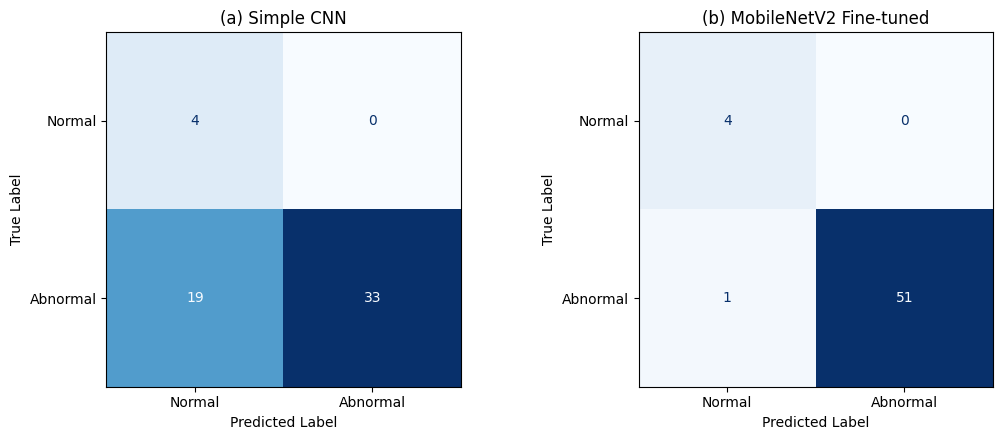

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrices จาก Test set เดียวกัน
cm_simple = np.array([
    [4, 0],
    [19, 33]
])

cm_mobilenet = np.array([
    [4, 0],
    [1, 51]
])

labels = ["Normal", "Abnormal"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# -------------------------------
# (a) Simple CNN
# -------------------------------
ConfusionMatrixDisplay(
    confusion_matrix=cm_simple,
    display_labels=labels
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

axes[0].set_title("(a) Simple CNN")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# -------------------------------
# (b) MobileNetV2 Fine-tuned
# -------------------------------
ConfusionMatrixDisplay(
    confusion_matrix=cm_mobilenet,
    display_labels=labels
).plot(
    ax=axes[1],
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

axes[1].set_title("(b) MobileNetV2 Fine-tuned")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

ใช่ครับ **รูปนี้ถูกต้องและเหมาะมากสำหรับใช้เป็นรูปหลักในหัวข้อ 4.4** เพราะเห็นความแตกต่างของสองโมเดลทันที

จากรูป Simple CNN จำแนก Normal ถูก 4/4 ภาพ แต่ตรวจพบ Abnormal ถูกเพียง 33/52 ภาพ และเกิด False Negative ถึง 19 ภาพ ขณะที่ MobileNetV2 Fine-tuned ตรวจพบ Abnormal ถูก 51/52 ภาพ เหลือ False Negative เพียง 1 ภาพ และยังคงจำแนก Normal ถูกทั้งหมด 4/4 ภาพ

ดังนั้นจุดเด่นที่ควรเขียนอภิปรายคือ **MobileNetV2 Fine-tuned ลด False Negative จาก 19 ภาพเหลือ 1 ภาพ หรือลดลงประมาณ 94.7%** ซึ่งมีความหมายมากสำหรับงานตรวจจับความผิดปกติของมอเตอร์ เพราะ False Negative คือกรณีที่ระบบพลาดความผิดปกติและจำแนกเป็นสภาวะปกติ

ผมแนะนำชื่อรูปว่า:

> **รูปที่ X เมทริกซ์ความสับสนของแบบจำลอง Simple CNN และ MobileNetV2 หลังการ Fine-tuning บนชุดข้อมูลทดสอบ**

และข้อความวิเคราะห์ใต้รูปสามารถเขียนในงานวิจัยได้ว่า:

> จากรูปที่ X พบว่า แบบจำลอง Simple CNN สามารถจำแนกภาพสภาวะปกติได้ถูกต้องทั้ง 4 ภาพ แต่สามารถจำแนกภาพสภาวะผิดปกติได้ถูกต้องเพียง 33 จาก 52 ภาพ โดยมีภาพสภาวะผิดปกติจำนวน 19 ภาพถูกจำแนกผิดเป็นสภาวะปกติ ในขณะที่แบบจำลอง MobileNetV2 หลังการ Fine-tuning สามารถจำแนกภาพสภาวะปกติได้ถูกต้องทั้ง 4 ภาพ และจำแนกภาพสภาวะผิดปกติได้ถูกต้อง 51 จาก 52 ภาพ โดยมีการจำแนกผิดเพียง 1 ภาพ ส่งผลให้จำนวน False Negative ลดลงจาก 19 ภาพเหลือ 1 ภาพ หรือประมาณร้อยละ 94.7 แสดงให้เห็นว่าแบบจำลองที่พัฒนาด้วย Transfer Learning และ Fine-tuning สามารถเรียนรู้คุณลักษณะเชิงพื้นที่ของรูปแบบความร้อนที่เกี่ยวข้องกับสภาวะผิดปกติได้ดีกว่าแบบจำลอง Simple CNN

**รูปนี้เก็บไว้ใช้ใน paper ได้เลยครับ ไม่ต้องแก้อะไรเพิ่มเติม**

ขั้นต่อไป ผมเห็นด้วยกับแผนเดิมว่าเราควรทำ **Error Analysis ของ 1 ภาพที่ MobileNetV2 ทำนายผิด** ก่อน เพราะจะทำให้เราอธิบายได้ว่าความผิดพลาดที่เหลือเกิดกับ fault class ใด และภาพนั้นมีลักษณะอย่างไร จากนั้นจึงปิดหัวข้อ 4.4 ด้วยตารางเปรียบเทียบผลสุดท้ายครับ


ได้ครับ ต่อไปทำ Error Analysis ของ MobileNetV2 Fine-tuned เพื่อค้นหาว่า 1 ภาพที่โมเดลทำนายผิดคือภาพใด อยู่ใน fault class ไหน และโมเดลให้ probability เท่าใด

ขั้นตอนที่ 1 — หา index ของภาพที่ทำนายผิด

ใช้ y_true และ probability ของ MobileNetV2 ที่เราใช้ตอนประเมิน Test set ก่อนหน้านี้ครับ ถ้าตัวแปร probability ของคุณชื่อ y_prob_mobile ให้รัน:

In [ ]:
import numpy as np

# Prediction จาก MobileNetV2
y_pred_mobile = (y_test_prob >= 0.5).astype(int)

# หา index ที่ทำนายผิด
wrong_idx = np.where(y_true != y_pred_mobile)[0]

print("Number of misclassified images:", len(wrong_idx))
print("Misclassified indices:", wrong_idx)

for idx in wrong_idx:
    print("\nIndex       :", idx)
    print("True label  :", "Abnormal" if y_true[idx] == 1 else "Normal")
    print("Predicted   :", "Abnormal" if y_pred_mobile[idx] == 1 else "Normal")
    print("Probability :", y_test_prob[idx])

Number of misclassified images: 1
Misclassified indices: [36]

Index       : 36
True label  : Abnormal
Predicted   : Normal
Probability : 0.48024487


ดีครับ ตอนนี้เรารู้แล้วว่า ภาพที่ทำนายผิดมีเพียง 1 ภาพ และเป็นกรณี False Negative:

Index = 36
True label = Abnormal
Predicted = Normal
P(Abnormal) = 0.4802

จุดนี้น่าสนใจมาก เพราะ probability อยู่ ใกล้ threshold 0.5 มาก ต่างกันเพียงประมาณ 0.0198 เท่านั้น ดังนั้นภาพนี้น่าจะเป็น borderline sample มากกว่าจะเป็นกรณีที่โมเดลมั่นใจผิดอย่างรุนแรง

ขั้นต่อไปคือหาให้ได้ว่า Index 36 คือไฟล์ไหน อยู่ใน Fault Folder ใด แล้วแสดงภาพออกมาดูครับ

ใช้โค้ดนี้:

In [ ]:
import numpy as np

# ==========================================
# STEP 14: Identify misclassified sample
# ==========================================

idx = wrong_idx[0]

row = test_df.iloc[idx]

print("===== Misclassified Sample =====")
print("Index       :", idx)
print("Folder      :", row["Folder"])
print("File        :", row["File"])
print("True label  :", row["Class"])
print("Probability :", y_test_prob[idx])
print(
    "Predicted   :",
    "Abnormal" if y_test_prob[idx] >= 0.5 else "Normal"
)

===== Misclassified Sample =====
Index       : 36
Folder      : A&C&B10
File        : 106.bmp
True label  : Abnormal
Probability : 0.48024487
Predicted   : Normal


ขั้นต่อไป: แสดงภาพ 106.bmp

สร้าง Cell ใหม่และใช้ตัวแปร y_test_prob ให้ตรงกับ Notebook ของเราครับ

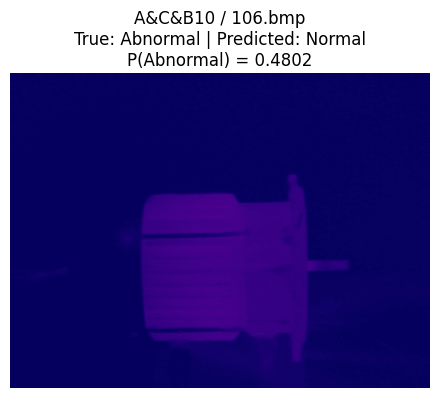

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Misclassified sample
idx = wrong_idx[0]
row = test_df.iloc[idx]

# Image path
img_path = MOTOR_DIR / row["Folder"] / row["File"]

# Load image
img = Image.open(img_path)

# Display
plt.figure(figsize=(5, 4))
plt.imshow(img)

plt.title(
    f'{row["Folder"]} / {row["File"]}\n'
    f'True: Abnormal | Predicted: Normal\n'
    f'P(Abnormal) = {y_test_prob[idx]:.4f}'
)

plt.axis("off")
plt.tight_layout()
plt.show()

ใช่ครับ จากจุดนี้เราเข้าสู่ การสรุปผลการทดลองและอภิปรายผล ได้แล้ว เพราะการทดลองหลักครบแล้วทั้ง Simple CNN, MobileNetV2 Stage 1, Fine-tuning, Test Evaluation, Confusion Matrix และ Error Analysis

ผมมองว่า ไม่จำเป็นต้องเขียนโค้ดเพิ่มมากแล้ว แต่ยังมีอีก 2 อย่างที่ควรทำ เพื่อให้ผลการทดลองพร้อมสำหรับเขียนบทความอย่างสมบูรณ์

อย่างแรกคือสร้าง ตารางสรุปผลอัตโนมัติ จากค่าที่ได้จริง เพื่อป้องกันการพิมพ์ตัวเลขผิด:

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Simple CNN",
        "MobileNetV2 Fine-tuned"
    ],
    "Accuracy": [
        0.6607,
        0.9821
    ],
    "Macro Precision": [
        0.5870,
        0.9000
    ],
    "Macro Recall": [
        0.8173,
        0.9904
    ],
    "Macro F1": [
        0.5364,
        0.9396
    ],
    "Balanced Accuracy": [
        0.8173,
        0.9904
    ],
    "MCC": [
        0.3322,
        0.8858
    ],
    "ROC-AUC": [
        0.6346,
        1.0000
    ],
    "PR-AUC": [
        0.9685,
        1.0000
    ],
    "False Negative": [
        19,
        1
    ]
})

display(results_df.round(4))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Balanced Accuracy,MCC,ROC-AUC,PR-AUC,False Negative
0,Simple CNN,0.6607,0.587,0.8173,0.5364,0.8173,0.3322,0.6346,0.9685,19
1,MobileNetV2 Fine-tuned,0.9821,0.900,0.9904,0.9396,0.9904,0.8858,1.0000,1.0000,1


อย่างที่สอง ผมแนะนำให้คำนวณ เปอร์เซ็นต์การปรับปรุงของ MobileNetV2 เมื่อเทียบกับ Simple CNN เพราะช่วยเขียน Discussion ได้ชัดขึ้น เช่น Macro F1 และ False Negative

In [ ]:
acc_improvement = (
    (0.9821 - 0.6607) / 0.6607
) * 100

f1_improvement = (
    (0.9396 - 0.5364) / 0.5364
) * 100

fn_reduction = (
    (19 - 1) / 19
) * 100

print(f"Accuracy improvement : {acc_improvement:.2f}%")
print(f"Macro F1 improvement : {f1_improvement:.2f}%")
print(f"False Negative reduction : {fn_reduction:.2f}%")

Accuracy improvement : 48.65%
Macro F1 improvement : 75.17%
False Negative reduction : 94.74%
